#Sujet : Plateforme BI d'Aide à la Décision Commerciale - Dataset Olist

In [ ]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## SECTION 1 — CHARGEMENT DU DATASET

In [ ]:
# Le dataset Olist est composé de plusieurs tables relationnelles (commandes,
# clients, produits, paiements, avis...). On les charge toutes dans un
# dictionnaire pour garder une structure flexible avant la fusion finale.

import kagglehub

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
dataframes = {}
for file in csv_files:
    name = file.replace('.csv', '').replace('olist_', '').replace('_dataset', '')
    dataframes[name] = pd.read_csv(os.path.join(path, file))
    print(f"{name}: {dataframes[name].shape}")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce
customers: (99441, 5)
sellers: (3095, 4)
order_reviews: (99224, 7)
order_items: (112650, 7)
products: (32951, 9)
geolocation: (1000163, 5)
product_category_name_translation: (71, 2)
orders: (99441, 8)
order_payments: (103886, 5)


## SECTION 2 — EXPLORATION INITIALE (info, describe, types)

In [ ]:
# Obj : comprendre la structure de chaque table avant tout traitement
# (types de colonnes, distributions statistiques, aperçu des données).

def explore_dataframe(name, df):
    print("=" * 80)
    print(f"TABLE : {name}")
    print("=" * 80)
    print("\n--- Shape ---")
    print(df.shape)
    print("\n--- Info ---")
    df.info()
    print("\n--- Types de colonnes ---")
    print(df.dtypes)
    print("\n--- Statistiques numériques ---")
    display(df.describe())
    print("\n--- Statistiques catégorielles ---")
    display(df.describe(include=['object']))
    print("\n--- Aperçu ---")
    display(df.head())

for name, df in dataframes.items():
    explore_dataframe(name, df)

TABLE : customers

--- Shape ---
(99441, 5)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- Types de colonnes ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

--- Statistiques numériques ---


,customer_zip_code_prefix
count,"99,441.00"
mean,"35,137.47"
std,"29,797.94"
min,"1,003.00"
25%,"11,347.00"
50%,"24,416.00"
75%,"58,900.00"
max,"99,990.00"



--- Statistiques catégorielles ---


,customer_id,customer_unique_id,customer_city,customer_state
count,99441,99441,99441,99441
unique,99441,96096,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP
freq,1,17,15540,41746



--- Aperçu ---


...

,payment_sequential,payment_installments,payment_value
count,"103,886.00","103,886.00","103,886.00"
mean,1.09,2.85,154.10
std,0.71,2.69,217.49
min,1.00,0.00,0.00
25%,1.00,1.00,56.79
50%,1.00,1.00,100.00
75%,1.00,4.00,171.84
max,29.00,24.00,"13,664.08"



--- Statistiques catégorielles ---


,order_id,payment_type
count,103886,103886
unique,99440,5
top,fa65dad1b0e818e3ccc5cb0e39231352,credit_card
freq,29,76795



--- Aperçu ---


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


un volume global de 99 441 commandes, 32 951 produits et 3 095 vendeurs, le jeu de données met en évidence une concentration géographique marquée autour de l'État de São Paulo, qui regroupe à lui seul 42 % des acheteurs et 60 % des vendeurs. Du côté de la clientèle, bien qu'on compte près de 100 000 transactions enregistrées, on ne dénombre en réalité que 96 096 clients uniques. Cela traduit un taux de réachat particulièrement faible d'environ 3,3 %, indiquant que la quasi-totalité des consommateurs n'effectue qu'un seul achat sur la plateforme.

Sur le plan opérationnel et financier, la plateforme affiche une excellente efficacité avec 97 % de commandes livrées avec succès. Le comportement d'achat se caractérise par des paniers très épurés de 1,14 article en moyenne, un prix produit moyen de 120,65 R et des frais de port moyens avoisinant les 20 R$. Les habitudes de paiement sont très représentatives du marché brésilien : la carte de crédit est le moyen de règlement prédominant (74 % des transactions) et le paiement échelonné y est ancré (2,85 mensualités en moyenne, atteignant parfois jusqu'à 24 échéances). L'expérience globale reste positive avec une note moyenne d'évaluation de 4,09 sur 5, bien que la majorité des utilisateurs déposent leur note sans rédiger de commentaire textuel.

In [ ]:
# Avant toute imputation, on quantifie systématiquement : valeurs manquantes,
# doublons, valeurs aberrantes (IQR) et incohérences métier. Cet audit guide
# toutes les décisions de nettoyage

### 3.1 Valeurs manquantes

[customers] Aucune valeur manquante
[sellers] Aucune valeur manquante
[order_reviews] Valeurs manquantes :


,Valeurs manquantes,Pourcentage (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70


[order_items] Aucune valeur manquante
[products] Valeurs manquantes :


,Valeurs manquantes,Pourcentage (%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


[geolocation] Aucune valeur manquante
[product_category_name_translation] Aucune valeur manquante
[orders] Valeurs manquantes :


,Valeurs manquantes,Pourcentage (%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


[order_payments] Aucune valeur manquante


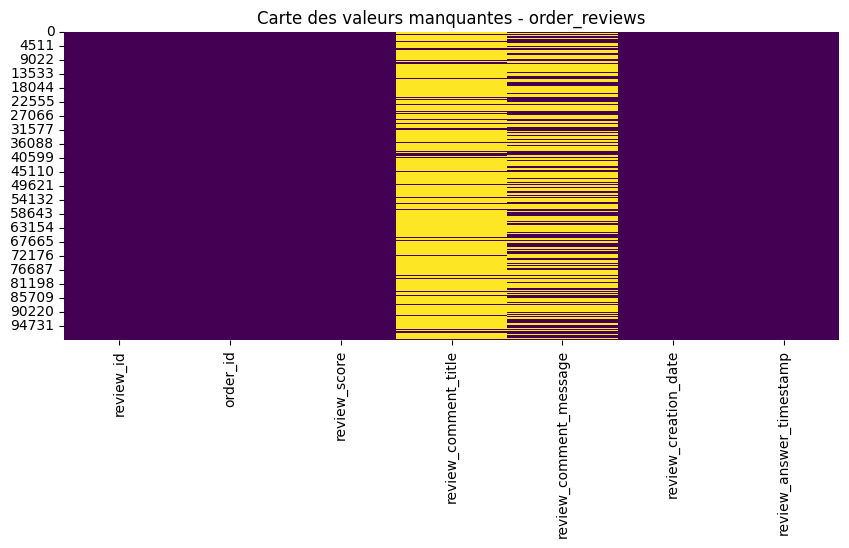

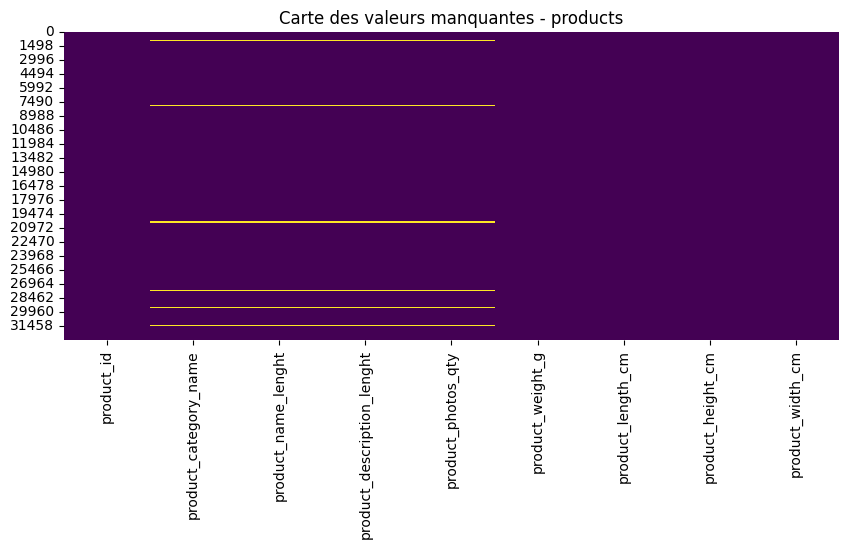

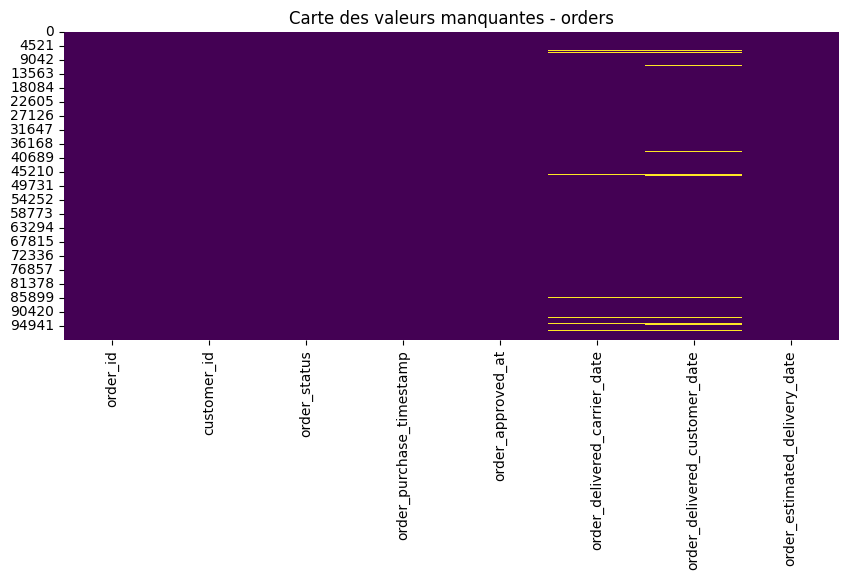

In [ ]:
def missing_values_report(df, name):
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    report = pd.DataFrame({'Valeurs manquantes': missing, 'Pourcentage (%)': missing_pct.round(2)})
    report = report[report['Valeurs manquantes'] > 0].sort_values('Pourcentage (%)', ascending=False)
    if report.empty:
        print(f"[{name}] Aucune valeur manquante")
    else:
        print(f"[{name}] Valeurs manquantes :")
        display(report)
    return report

for name, df in dataframes.items():
    missing_values_report(df, name)

for name, df in dataframes.items():
    if df.isnull().sum().sum() > 0:
        plt.figure(figsize=(10, 4))
        sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
        plt.title(f"Carte des valeurs manquantes - {name}")
        plt.show()

Dans la table **order_reviews**, la forte proportion de **titre** (88,34 %) et de **messages** (58,70 %) manquants correspond à un comportement client très classique en e-commerce : la grande majorité des acheteurs se contente d'attribuer une note étoilée sans rédiger de commentaire.

De la même manière, les absences constatées dans la table **orders** retracent fidèlement le tunnel de conversion. Les 2 965 **dates de livraison client** manquantes (2,98 %), tout comme **les dates d'expédition** (1,79 %) ou **d'approbation** (0,16 %), ne sont pas des données corrompues mais représentent simplement les commandes annulées ou encore en cours d'acheminement au moment de la création de la base.

Le seul point d'attention technique réside dans la table **products**, où 610 **articles** (1,85 %) n'ont ni **catégorie**, ni **métadonnées** de **description** et où 2 produits manquent de poids et de dimensions physiques.



### 3.2 Doublons

In [ ]:
for name, df in dataframes.items():
    n_dup = df.duplicated().sum()
    print(f"{name}: {n_dup} doublons ({(n_dup / len(df) * 100):.2f}%)")

customers: 0 doublons (0.00%)
sellers: 0 doublons (0.00%)
order_reviews: 0 doublons (0.00%)
order_items: 0 doublons (0.00%)
products: 0 doublons (0.00%)
geolocation: 261831 doublons (26.18%)
product_category_name_translation: 0 doublons (0.00%)
orders: 0 doublons (0.00%)
order_payments: 0 doublons (0.00%)


NB : le taux élevé de doublons sur 'geolocation' (~26%) sera  traité par agrégation si plusieurs adresses partagent un même code postal avec des coordonnées géographiques quasi identiques

### 3.3 Valeurs aberrantes (méthode IQR)


--- Outliers dans order_reviews ---


,nb_outliers,pct,borne_inf,borne_sup,min,max
review_score,"14,575.00",14.69,2.50,6.50,1.00,5.00



--- Outliers dans order_items ---


,nb_outliers,pct,borne_inf,borne_sup,min,max
order_item_id,"13,984.00",12.41,1.00,1.00,1.00,21.00
price,"8,427.00",7.48,-102.60,277.40,0.85,"6,735.00"
freight_value,"12,134.00",10.77,0.98,33.25,0.00,409.68



--- Outliers dans products ---


,nb_outliers,pct,borne_inf,borne_sup,min,max
product_name_lenght,290.00,0.88,19.50,79.50,5.00,76.00
product_description_lenght,"2,078.00",6.31,-610.50,"1,921.50",4.00,"3,992.00"
product_photos_qty,849.00,2.58,-2.00,6.00,1.00,20.00
product_weight_g,"4,551.00",13.81,"-2,100.00","4,300.00",0.00,"40,425.00"
product_length_cm,"1,380.00",4.19,-12.00,68.00,7.00,105.00
product_height_cm,"1,892.00",5.74,-11.50,40.50,2.00,105.00
product_width_cm,912.00,2.77,-7.50,52.50,6.00,118.00



--- Outliers dans geolocation ---


,nb_outliers,pct,borne_inf,borne_sup,min,max
geolocation_lat,"168,240.00",16.82,-29.04,-14.54,-36.61,45.07
geolocation_lng,"42,348.00",4.23,-55.78,-36.56,-101.47,121.11



--- Outliers dans order_payments ---


,nb_outliers,pct,borne_inf,borne_sup,min,max
payment_sequential,"4,526.00",4.36,1.00,1.00,1.00,29.00
payment_installments,"6,313.00",6.08,-3.50,8.50,0.00,24.00
payment_value,"7,981.00",7.68,-115.78,344.41,0.00,"13,664.08"


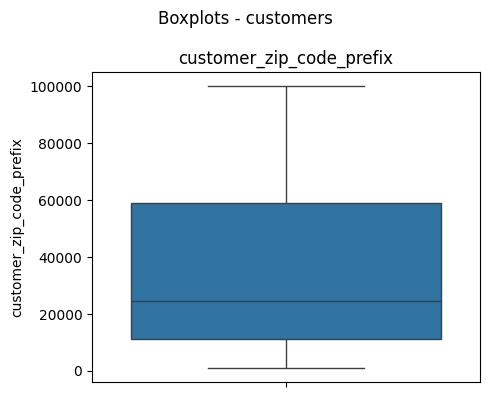

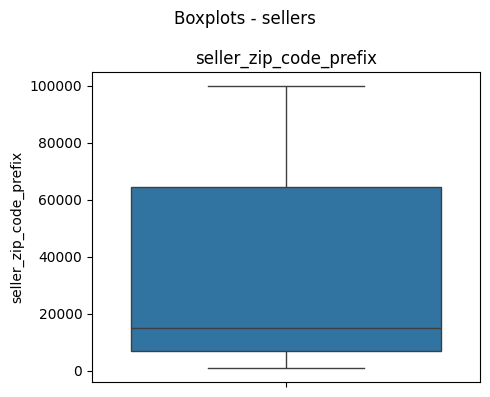

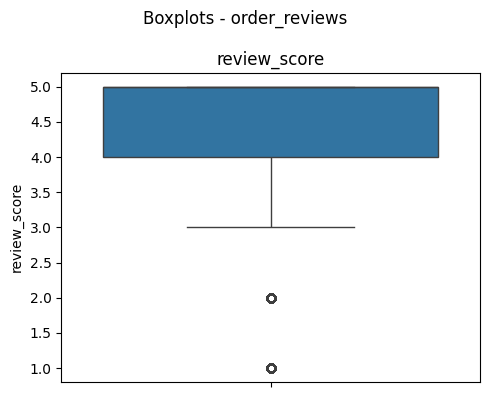

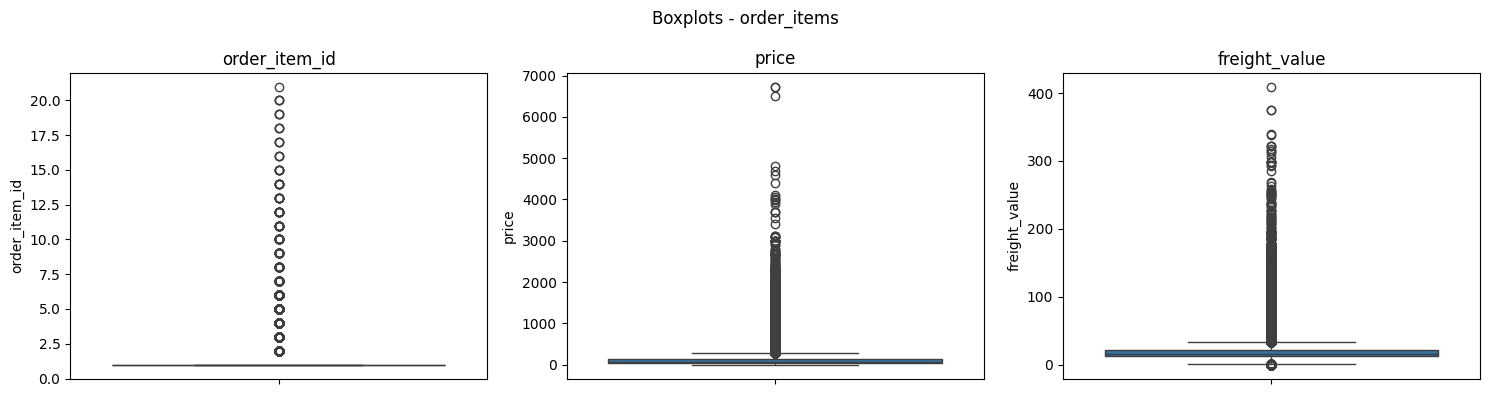

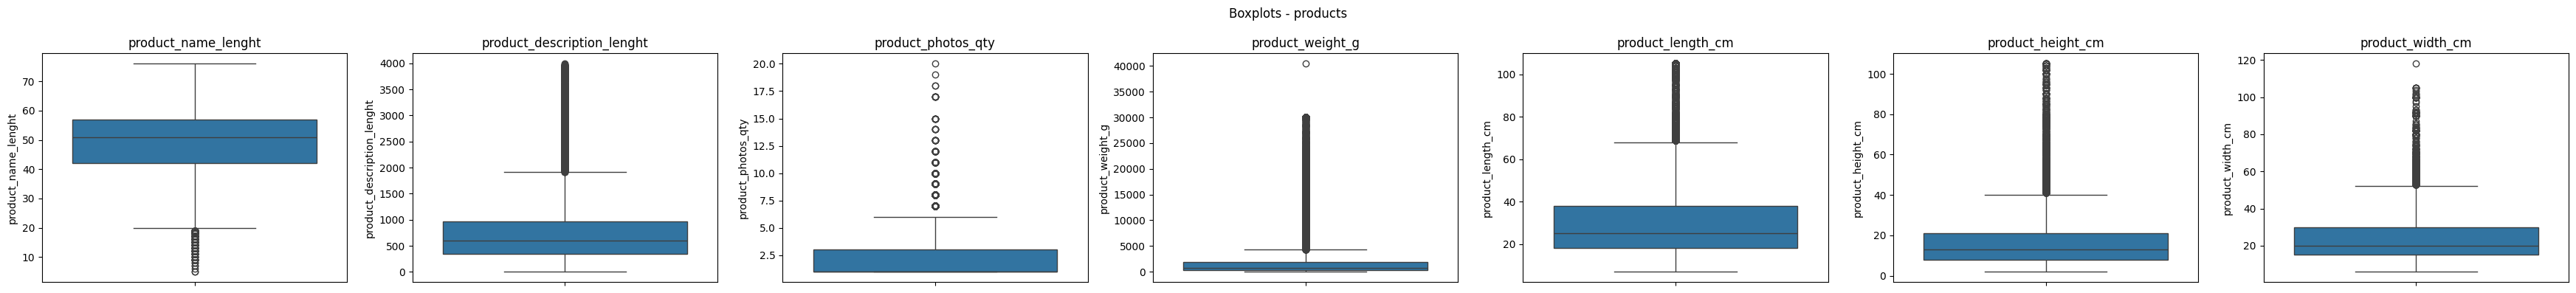

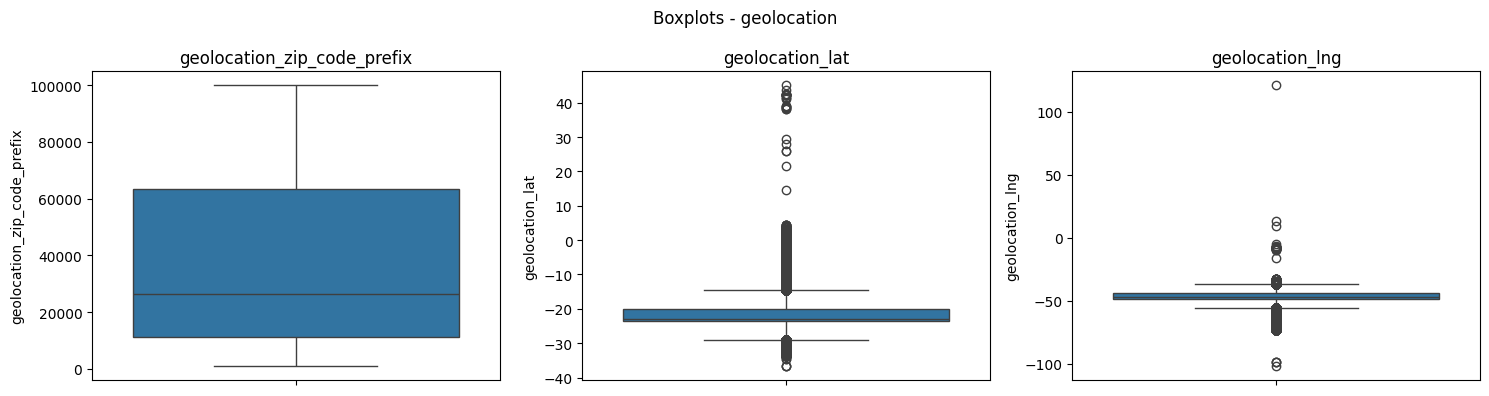

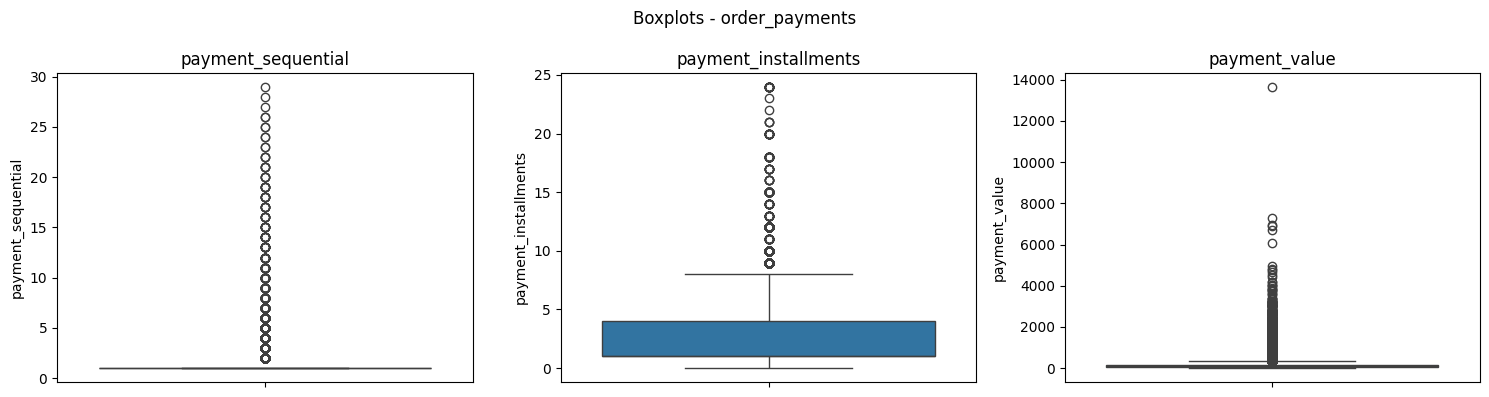

                              product_id    price  freight_value
3556    489ae2aa008f021502940f251d4cce7f 6,735.00         194.31
112233  69c590f7ffc7bf8db97190b6cb6ed62e 6,729.00         193.21
107841  1bdf5e6731585cf01aa8169c7028d6ad 6,499.00         227.66
74336   a6492cc69376c469ab6f61d8f44de961 4,799.00         151.34
11249   c3ed642d592594bb648ff4a04cee2747 4,690.00          74.34
62086   259037a6a41845e455183f89c5035f18 4,590.00          91.78
29193   a1beef8f3992dbd4cd8726796aa69c53 4,399.87         113.45
45843   6cdf8fc1d741c76586d8b6b15e9eef30 4,099.99          75.27
78310   dd113cb02b2af9c8e5787e8f1f0722f6 4,059.00         104.51
59137   6902c1962dd19d540807d0ab8fade5c6 3,999.90          17.01


In [ ]:
def detect_outliers_iqr(df, name):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    outlier_summary = {}
    for col in numeric_cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if len(outliers) > 0:
            outlier_summary[col] = {
                'nb_outliers': len(outliers), 'pct': round(len(outliers) / len(df) * 100, 2),
                'borne_inf': lower, 'borne_sup': upper, 'min': df[col].min(), 'max': df[col].max()
            }
    if outlier_summary:
        print(f"\n--- Outliers dans {name} ---")
        display(pd.DataFrame(outlier_summary).T)
    return outlier_summary

for name, df in dataframes.items():
    detect_outliers_iqr(df, name)

def plot_boxplots(df, name):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) == 0:
        return
    n = len(numeric_cols)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        sns.boxplot(y=df[col], ax=ax)
        ax.set_title(col)
    plt.suptitle(f"Boxplots - {name}")
    plt.tight_layout()
    plt.show()

for name, df in dataframes.items():
    plot_boxplots(df, name)

# Vérification ciblée : les prix élevés (jusqu'à 6735 R$) sont-ils des erreurs
# de saisie ou des produits légitimement chers (électroménager, meubles...) ?
items = dataframes['order_items']
print(items.nlargest(10, 'price')[['product_id', 'price', 'freight_value']])
# -> Conclusion : outliers légitimes, conservés tels quels (pas de suppression).

####**Dans order_reviews**,
les notes 1 et 2 sont détectées comme outliers par la méthode IQR, mais elles représentent simplement des avis très négatifs et doivent être conservées.

####**Dans order_items**,
les prix élevés (jusqu'à 6 735 BRL) et certains frais de livraison importants correspondent à des produits coûteux ou volumineux. De même, un nombre élevé d'articles dans une commande (order_item_id jusqu'à 21) reste cohérent avec l'activité d'un site e-commerce.

####**Dans products**,
les valeurs extrêmes observées pour le poids, les dimensions ou la longueur des descriptions traduisent principalement la diversité des produits vendus sur la plateforme. Par exemple, certains articles lourds atteignent plus de 40 kg.

####**Dans geolocation**,
les coordonnées géographiques atypiques peuvent provenir de localisations éloignées, d'erreurs de géocodage ou de données enregistrées hors du territoire principal étudié.

####**Dans order_payments**,
les montants élevés et le nombre important de mensualités reflètent des achats de forte valeur ou des facilités de paiement proposées aux clients.




### 3.4 Incohérences métier

In [ ]:
orders = dataframes['orders']
date_cols = [c for c in orders.columns if 'date' in c.lower() or 'timestamp' in c.lower()]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

incoherent = orders[orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']]
print(f"Commandes livrées avant d'être passées : {len(incoherent)}")  # -> 0, aucune incohérence

payments = dataframes['order_payments']
print(f"Prix <= 0 : {(items['price'] <= 0).sum()}")
print(f"Frais de port négatifs : {(items['freight_value'] < 0).sum()}")
print(f"payment_installments = 0 : {(payments['payment_installments'] == 0).sum()}")  # -> 2, incohérent
print(f"payment_value = 0 : {(payments['payment_value'] == 0).sum()}")  # -> 9, à investiguer

reviews = dataframes['order_reviews']
invalid_scores = reviews[~reviews['review_score'].between(1, 5)]
print(f"Scores de review invalides : {len(invalid_scores)}")  # -> 0

delivered_no_date = orders[(orders['order_status'] == 'delivered') &
                            (orders['order_delivered_customer_date'].isnull())]
print(f"Statut 'delivered' sans date de livraison : {len(delivered_no_date)}")  # -> incohérence à corriger

Commandes livrées avant d'être passées : 0
Prix <= 0 : 0
Frais de port négatifs : 0
payment_installments = 0 : 2
payment_value = 0 : 9
Scores de review invalides : 0
Statut 'delivered' sans date de livraison : 8


Aucune commande n'a été livrée avant sa date d'achat, aucun prix négatif ou nul n'a été détecté et tous les scores d'évaluation sont conformes à l'échelle attendue (1 à 5).

Seules quelques anomalies mineures ont été identifiées : **2 paiements avec `payment_installments = 0`**, **9 paiements avec `payment_value = 0`** et **8 commandes marquées comme "delivered" sans date de livraison renseignée**.


## SECTION 4 — NETTOYAGE ET IMPUTATION CONTEXTUELLE

In [ ]:
#chaque valeur manquante ou incohérente est traitée selon
# une logique métier et relationnelle (produit -> vendeur, commande -> route
# logistique...) plutôt que par une moyenne/médiane globale aveugle. Chaque
# imputation est accompagnée d'un flag de traçabilité pour pouvoir isoler les
# valeurs estimées des valeurs réelles dans les analyses futures.

### 4.1 Reviews : commentaires manquants (non-réponse, pas une anomalie)

In [ ]:
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('no_title')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('no_comment')
dataframes['order_reviews'] = reviews

### 4.2 Products : catégorie manquante (610 produits)

In [ ]:
# Étape 1 : vérifier que ces produits ont bien été vendus (impact réel sur l'analyse)
products = dataframes['products']
missing_cat_ids = products[products['product_category_name'].isnull()]['product_id']
sold = items[items['product_id'].isin(missing_cat_ids)]
print(f"Produits sans catégorie : {len(missing_cat_ids)} | dont vendus : {sold['product_id'].nunique()}")

# Étape 2 : déduction de la catégorie via le vendeur dominant (un vendeur a
# généralement une spécialité produit) plutôt qu'un fillna('unknown') aveugle
product_seller = items[['product_id', 'seller_id']].drop_duplicates()
seller_top_category = (
    items.merge(products[['product_id', 'product_category_name']], on='product_id')
    .dropna(subset=['product_category_name'])
    .groupby('seller_id')['product_category_name']
    .agg(lambda x: x.mode()[0])
)

def infer_category(product_id):
    sellers = product_seller[product_seller['product_id'] == product_id]['seller_id']
    cats = seller_top_category.reindex(sellers).dropna()
    return cats.mode()[0] if not cats.empty else np.nan

products['product_category_name_imputed'] = products['product_category_name']
mask_cat = products['product_category_name'].isnull()
products.loc[mask_cat, 'product_category_name_imputed'] = products.loc[mask_cat, 'product_id'].apply(infer_category)
products['product_category_name_imputed'] = products['product_category_name_imputed'].fillna('non_categorized')

n_recovered = products.loc[mask_cat, 'product_category_name_imputed'].ne('non_categorized').sum()
print(f"Catégories récupérées via vendeur : {n_recovered} | non récupérables : {mask_cat.sum() - n_recovered}")


Produits sans catégorie : 610 | dont vendus : 610
Catégories récupérées via vendeur : 512 | non récupérables : 98


512 récupérées via le vendeur, 98 restent 'non_categorized' (aucun historique exploitable)

L'analyse a montré que 610 produits (1,85 % du catalogue) ne possédaient pas de catégorie renseignée.

Ces produits n'étaient pas des produits isolés puisqu'ils avaient tous déjà été vendus, ce qui permettait d'exploiter leur historique commercial.

En utilisant la catégorie dominante des vendeurs associés, 512 catégories (83,9 % des cas manquants) ont pu être récupérées automatiquement.

l'idée est en fait si un vendeur vend principalement des produits d'une certaine catégorie,alors un produit sans catégorie vendu par ce même vendeur a de fortes chances d'appartenir à cette catégorie.

cad=> Pour chaque produit sans catégorie :

Trouver son vendeur.
Regarder la catégorie dominante du vendeur (val pls frequente).
Retourner cette catégorie.

Les 98 produits restants ne disposaient pas d'informations suffisantes pour une inférence fiable(par exp un vendeur a achete seulement un produit dont l'etiquette categorie est vide dans ce cas l'historique est insuffisnat et la colonne seller_top_category reste vide) et ont donc été conservés dans une catégorie spécifique (non_categorized) afin de préserver la cohérence et la traçabilité des données.

### 4.3 Products : dimensions et caractéristiques textuelles manquantes

On va imputer les valeurs manquantes des caractéristiques textuelles et des dimensions physiques à l'aide de médianes adaptées au contexte. et remplacer ensuite la catégorie originale par la version corrigée et met à jour le dataset principal. on va conserver une cohérence entre les produits appartenant à une même catégorie.

In [ ]:
# Ces colonnes manquent sur les mêmes lignes que la catégorie (fiches produit
# jamais complétées par le vendeur) + 2 lignes isolées sur les dimensions.
cols_to_impute = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
                   'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

# Flag de traçabilité calculé AVANT toute imputation (fiche produit incomplète à l'origine)
products['is_incomplete_listing'] = products[cols_to_impute].isnull().any(axis=1).astype(int)

# Imputation par médiane de la catégorie (produits similaires = dimensions similaires),
# avec un filet de sécurité par médiane globale pour les groupes sans aucune valeur valide
# (ex: le groupe 'non_categorized', où toutes les lignes sont NaN par construction)
for col in cols_to_impute:
    products[col] = products.groupby('product_category_name_imputed')[col].transform(lambda x: x.fillna(x.median()))
    products[col] = products[col].fillna(products[col].median())

# Nettoyage : on ne garde qu'une seule colonne de catégorie (la version imputée)
products = products.drop(columns=['product_category_name'])
products = products.rename(columns={'product_category_name_imputed': 'product_category_name'})
dataframes['products'] = products

print(f"NaN restants dans products : {products.isnull().sum().sum()}")  # -> 0
print(f"Produits marqués incomplets (flag) : {products['is_incomplete_listing'].sum()}")

NaN restants dans products : 0
Produits marqués incomplets (flag) : 611


NB : 611 = 610 (textes manquants) + 2 (dimensions manquantes) - 1 (produit cumulant les deux)

les 610 catégories manquantes ont été imputées ou remplacées par non_categorized,les caractéristiques des produits (nom, description, photos, poids et dimensions) ont également été complétées.


indique que 611 produits étaient initialement incomplets avant le nettoyage. Ce nombre est légèrement supérieur aux 610 produits sans catégorie car 2 produits présentaient des valeurs manquantes sur les dimensions (poids, longueur, largeur ou hauteur) et l'un d'eux appartenait déjà aux 610 produits sans catégorie.

### 4.4 Order_payments : incohérences

In [ ]:
# installments = 0 logiquement impossible car un paiement implique >= 1 échéance
payments.loc[payments['payment_installments'] == 0, 'payment_installments'] = 1

# payment_value = 0 : vérifier si le montant total de la commande est réconcilié
# par d'autres lignes de paiement (vouchers fractionnés)
zero_pay = payments[payments['payment_value'] == 0]
for oid in zero_pay['order_id']:
    total_paid = payments[payments['order_id'] == oid]['payment_value'].sum()
    order_total = items[items['order_id'] == oid]['price'].sum() + items[items['order_id'] == oid]['freight_value'].sum()
    print(f"order {oid} | payé total: {total_paid:.2f} | montant commande: {order_total:.2f}")
# 6 lignes voucher : montant réconcilié (paiement fractionné légitime
# 3 lignes 'not_defined' : commandes réellement à 0 R$ (annulées), flag créé ci-dessous

zero_orders = ['4637ca194b6387e2d538dc89b124b0ee', '00b1cb0320190ca0daa2c88b35206009',
               'c8c528189310eaa44a745b8d9d26908b']
payments['is_zero_value_order'] = payments['order_id'].isin(zero_orders).astype(int)
dataframes['order_payments'] = payments

order 8bcbe01d44d147f901cd3192671144db | payé total: 74.16 | montant commande: 74.16
order fa65dad1b0e818e3ccc5cb0e39231352 | payé total: 457.99 | montant commande: 457.99
order 6ccb433e00daae1283ccc956189c82ae | payé total: 122.04 | montant commande: 122.04
order 4637ca194b6387e2d538dc89b124b0ee | payé total: 0.00 | montant commande: 0.00
order 00b1cb0320190ca0daa2c88b35206009 | payé total: 0.00 | montant commande: 0.00
order 45ed6e85398a87c253db47c2d9f48216 | payé total: 71.14 | montant commande: 71.14
order fa65dad1b0e818e3ccc5cb0e39231352 | payé total: 457.99 | montant commande: 457.99
order c8c528189310eaa44a745b8d9d26908b | payé total: 0.00 | montant commande: 0.00
order b23878b3e8eb4d25a158f57d96331b18 | payé total: 171.57 | montant commande: 171.57


L'analyse des neuf lignes présentant un montant de paiement nul (payment_value = 0) montre que six d'entre elles correspondent à des paiements fractionnés où d'autres transactions couvrent intégralement le montant de la commande.

Les trois cas restants concernent des commandes dont la valeur totale est également nulle.

Ces observations indiquent qu'il ne s'agit pas de valeurs manquantes mais de situations métier particulières. Afin d'en conserver la traçabilité, un indicateur is_zero_value_order a été créé pour identifier les trois commandes à valeur nulle.

payment_installments = 0 → corrigé en 1 car c'est une incohérence métier.

payment_value = 0 → analysé avant toute correction.

6 lignes voucher sont normales (paiements fractionnés).

3 commandes ont réellement une valeur totale de 0.

Ces 3 commandes ne sont pas supprimées ni modifiées ; elles sont simplement identifiées par le flag is_zero_value_order pour garder leur traçabilité dans les analyses futures.

### 4.5 Geolocation : dédoublonnage (26% de doublons)

In [ ]:
# Plusieurs adresses partagent un même code postal avec des coordonnées quasi
# identiques -> agrégation par zip_code_prefix pour éviter une explosion de
# lignes lors des futures jointures.
geo = dataframes['geolocation']
geo_clean = geo.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'median', 'geolocation_lng': 'median',
    'geolocation_city': lambda x: x.mode()[0], 'geolocation_state': lambda x: x.mode()[0]
}).reset_index()
dataframes['geolocation'] = geo_clean
print(f"Geolocation : {geo.shape[0]} -> {geo_clean.shape[0]} lignes après dédoublonnage")

Geolocation : 1000163 -> 19015 lignes après dédoublonnage


### 4.6 Orders : conversion des dates en datetime

In [ ]:
orders = dataframes['orders']
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
                     'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')
dataframes['order_items']['shipping_limit_date'] = pd.to_datetime(dataframes['order_items']['shipping_limit_date'])
dataframes['order_reviews']['review_creation_date'] = pd.to_datetime(dataframes['order_reviews']['review_creation_date'])
dataframes['order_reviews']['review_answer_timestamp'] = pd.to_datetime(dataframes['order_reviews']['review_answer_timestamp'])
dataframes['orders'] = orders

### 4.7 Orders : incohérences temporelles (commandes 'delivered' avec dates manquantes)

In [ ]:
# Une commande livrée au client implique nécessairement un passage par le
# transporteur et une approbation préalable. Toute date manquante sur un
# statut 'delivered' est donc une incohérence, corrigée par régression simple
# sur le délai médian de l'étape logistique concernée
customers = dataframes['customers']
orders['delivery_date_imputed'] = 0

# order_delivered_customer_date manquante (8 cas) -> délai médian de transit par état client
inconsistent = orders[(orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isnull())]
orders_complete = orders.dropna(subset=['order_delivered_carrier_date', 'order_delivered_customer_date']).copy()
orders_complete = orders_complete.merge(customers[['customer_id', 'customer_state']], on='customer_id')
orders_complete['transit_days'] = (orders_complete['order_delivered_customer_date'] -
                                    orders_complete['order_delivered_carrier_date']).dt.total_seconds() / 86400
median_transit_by_state = orders_complete.groupby('customer_state')['transit_days'].median()

inconsistent = inconsistent.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
for idx, row in inconsistent.iterrows():
    if pd.notnull(row['order_delivered_carrier_date']):
        median_days = median_transit_by_state.get(row['customer_state'], orders_complete['transit_days'].median())
        estimated_date = row['order_delivered_carrier_date'] + pd.Timedelta(days=median_days)
    else:
        estimated_date = row['order_estimated_delivery_date']
    orders.loc[orders['order_id'] == row['order_id'], 'order_delivered_customer_date'] = estimated_date
    orders.loc[orders['order_id'] == row['order_id'], 'delivery_date_imputed'] = 1

# order_delivered_carrier_date manquante (2 cas, statut delivered) -> délai médian de préparation
missing_carrier_delivered = orders[(orders['order_status'] == 'delivered') &
                                    (orders['order_delivered_carrier_date'].isnull())]
orders_ref = orders.dropna(subset=['order_approved_at', 'order_delivered_carrier_date']).copy()
orders_ref['prep_days'] = (orders_ref['order_delivered_carrier_date'] - orders_ref['order_approved_at']).dt.total_seconds() / 86400
median_prep_days = orders_ref['prep_days'].median()

for idx, row in missing_carrier_delivered.iterrows():
    base_date = row['order_approved_at'] if pd.notnull(row['order_approved_at']) else row['order_purchase_timestamp']
    orders.loc[orders['order_id'] == row['order_id'], 'order_delivered_carrier_date'] = base_date + pd.Timedelta(days=median_prep_days)
    orders.loc[orders['order_id'] == row['order_id'], 'delivery_date_imputed'] = 1

# order_approved_at manquante (14 cas, statut delivered) -> délai médian d'approbation
missing_approved_delivered = orders[(orders['order_status'] == 'delivered') & (orders['order_approved_at'].isnull())]
orders_ref2 = orders.dropna(subset=['order_purchase_timestamp', 'order_approved_at']).copy()
orders_ref2['approval_days'] = (orders_ref2['order_approved_at'] - orders_ref2['order_purchase_timestamp']).dt.total_seconds() / 86400
median_approval_days = orders_ref2['approval_days'].median()

for idx, row in missing_approved_delivered.iterrows():
    estimated = row['order_purchase_timestamp'] + pd.Timedelta(days=median_approval_days)
    orders.loc[orders['order_id'] == row['order_id'], 'order_approved_at'] = estimated
    orders.loc[orders['order_id'] == row['order_id'], 'delivery_date_imputed'] = 1

orders['delivery_date_imputed'] = orders['delivery_date_imputed'].fillna(0)
dataframes['orders'] = orders

# les seules NaN restantes doivent concerner des commandes NON
# livrées (canceled, shipped, processing, unavailable, invoiced, created,
# approved)
for col in ['order_delivered_customer_date', 'order_delivered_carrier_date', 'order_approved_at']:
    remaining = orders[orders[col].isnull()]
    print(f"\n{col} - statuts restants :")
    print(remaining['order_status'].value_counts())


order_delivered_customer_date - statuts restants :
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64

order_delivered_carrier_date - statuts restants :
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
Name: count, dtype: int64

order_approved_at - statuts restants :
order_status
canceled    141
created       5
Name: count, dtype: int64


### 4.8 Bilan final du nettoyage

In [ ]:
print("=" * 60)
print("BILAN FINAL DU NETTOYAGE")
print("=" * 60)
for name, df in dataframes.items():
    print(f"{name:12} | NaN: {df.isnull().sum().sum():6} | Doublons: {df.duplicated().sum()}")
print("\nColonnes de traçabilité créées :")
print("- products['is_incomplete_listing']")
print("- orders['delivery_date_imputed']")
print("- order_payments['is_zero_value_order']")

BILAN FINAL DU NETTOYAGE
customers    | NaN:      0 | Doublons: 0
sellers      | NaN:      0 | Doublons: 0
order_reviews | NaN:      0 | Doublons: 0
order_items  | NaN:      0 | Doublons: 0
products     | NaN:      0 | Doublons: 0
geolocation  | NaN:      0 | Doublons: 0
product_category_name_translation | NaN:      0 | Doublons: 0
orders       | NaN:   4884 | Doublons: 0
order_payments | NaN:      0 | Doublons: 0

Colonnes de traçabilité créées :
- products['is_incomplete_listing']
- orders['delivery_date_imputed']
- order_payments['is_zero_value_order']


In [ ]:
print("=" * 60)
print("VÉRIFICATION DES VALEURS MANQUANTES RESTANTES")
print("=" * 60)

for col in ['order_delivered_customer_date', 'order_delivered_carrier_date', 'order_approved_at']:
    remaining = orders[orders[col].isnull()]
    total_remaining = len(remaining)
    delivered_remaining = (remaining['order_status'] == 'delivered').sum()

    print(f"\n--- {col} ---")
    print(f"Total NaN restants : {total_remaining}")
    print(f"Dont statut 'delivered' : {delivered_remaining}  {'✅ OK' if delivered_remaining == 0 else '⚠️ PROBLÈME'}")
    print("\nRépartition par statut :")
    print(remaining['order_status'].value_counts())
    print(f"\nRépartition en % :")
    print((remaining['order_status'].value_counts(normalize=True) * 100).round(1).astype(str) + ' %')

VÉRIFICATION DES VALEURS MANQUANTES RESTANTES

--- order_delivered_customer_date ---
Total NaN restants : 2957
Dont statut 'delivered' : 0  ✅ OK

Répartition par statut :
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
created           5
approved          2
Name: count, dtype: int64

Répartition en % :
order_status
shipped        37.4 %
canceled       20.9 %
unavailable    20.6 %
invoiced       10.6 %
processing     10.2 %
created         0.2 %
approved        0.1 %
Name: proportion, dtype: object

--- order_delivered_carrier_date ---
Total NaN restants : 1781
Dont statut 'delivered' : 0  ✅ OK

Répartition par statut :
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
Name: count, dtype: int64

Répartition en % :
order_status
unavailable    34.2 %
canceled       30.9 %
invoiced       17.6 %
processing     16.9 %
created         0.3 %
approved   

## SECTION 5 — CONSTRUCTION DU MODÈLE EN ÉTOILE (fact_orders / fact_order_items)

###**creation du  fact_order_items — grain produit**

Afin d'éviter les problèmes de **duplication des mesures** et de respecter les différents niveaux de granularité du dataset Olist,
**deux tables de faits** complémentaires ont été construites.


###**Exemple**

Une commande peut avoir 3 produits

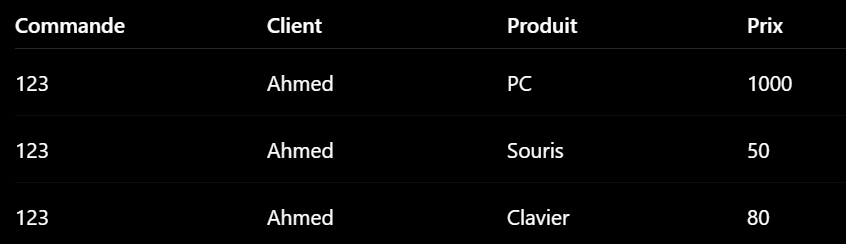

Les informations du client seraient répétées plusieurs fois.

Si on veut calculer le chiffre d'affaires global, cela fonctionne.

Mais si on veut connaître :

le nombre de produits vendus,
le vendeur le plus performant,
la catégorie la plus rentable,

on a besoin du détail produit par produit.

Ce qu'on prépare ici

On prépare la création de deux tables de faits complémentaires :

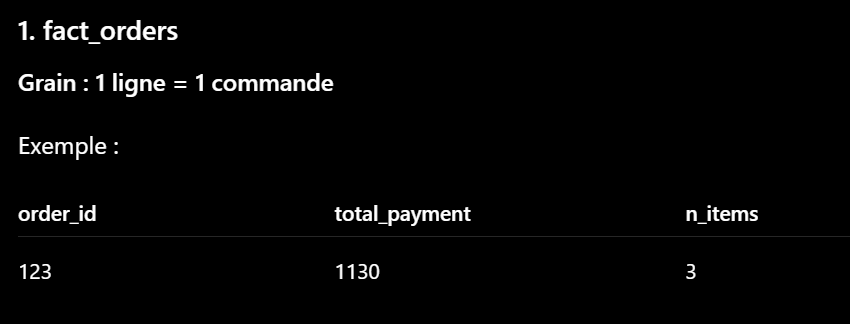

Utilisée pour :

chiffre d'affaires
taux de retard
satisfaction client
prévisions de ventes
KPI du dashboard


###2. fact_order_items

Grain : 1 ligne = 1 article acheté

Exemple :

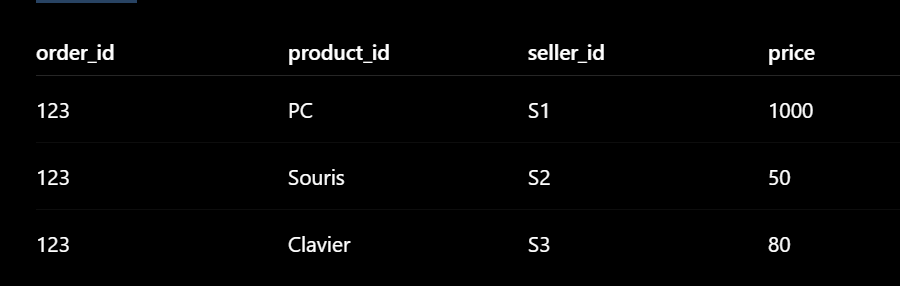

Utilisée pour :

analyse des produits, des catégories, des vendeurs, calcul des marges,
recommandations

SOLUTION

**La table fact_orders** est définie au grain **commande** (une ligne par commande) et centralise les indicateurs globaux tels que le **chiffre d'affaires**, **les frais de livraison** ou **les délais**.

**La table fact_order_items** est définie au grain **article** (une ligne par produit commandé) et permet les analyses détaillées par **produit**, **catégorie** ou **vendeur**.

Cette séparation garantit la cohérence des calculs analytiques

In [ ]:
# on récupère chacune des tables depuis le dictionnaire dataframes et les stocke
#dans des variables plus faciles à manipuler.

orders = dataframes['orders']
items = dataframes['order_items']
products = dataframes['products']
customers = dataframes['customers']
sellers = dataframes['sellers']
translation = dataframes['product_category_name_translation']
payments = dataframes['order_payments']
reviews = dataframes['order_reviews']

### 5.1 fact_order_items (grain produit)

On récupère le client ayant passé la commande, le statut de la commande, la date d'achat, la date réelle de livraison, la date prévue de livraison

---

On ajoute la catégorie du produit, son poids, ses dimensions

---

on ajoute de la traduction des catégories

---

On ajoute l'État du client, sa ville

---

On ajoute l'État du vendeur, sa ville

## Feature Engineering

###Une fois toutes les informations regroupées, on crée de nouvelles variables analytiques.

* **Valeur totale de l'article** Calcul: **Prix du produit+Frais de port** (représente le coût réel payé pour l'article)

* **Retard de livraison** Calcul:

Date réelle − Date estimée

Si
valeur négative → livré en avance
valeur nulle → livré à temps
valeur positive → livré en retard

* **Indicateur de retard**: Transformation du retard en variable binaire is_late

=> utile pour les modèles de classification.

* **Livraison dans le même État**: mesure l'effet de la distance logistique sur les délais. (meme etats ou etats differents)

* **Marge estimée**: On ne connaît pas le coût réel du produit.

On utilise  un indicateur approximatif : Prix − Frais de port

=> un proxy utile pour comparer les produits.

* **Ratio frais de port**: Prix du produit/Frais de port
	​
Exp
Produit = 100
Livraison = 20
20/100=0.20

Le transport représente alors 20 % du prix du produit.


In [ ]:
fact_order_items = (
    items
    .merge(orders[['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
                    'order_delivered_customer_date', 'order_estimated_delivery_date',
                    'delivery_date_imputed']], on='order_id', how='left')
    .merge(products[['product_id', 'product_category_name', 'product_weight_g', 'product_length_cm',
                      'product_height_cm', 'product_width_cm', 'is_incomplete_listing']], on='product_id', how='left')
    .merge(translation, on='product_category_name', how='left')
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(sellers[['seller_id', 'seller_state', 'seller_city']], on='seller_id', how='left')
)
fact_order_items['total_item_value'] = fact_order_items['price'] + fact_order_items['freight_value']
fact_order_items['delivery_delay_days'] = (fact_order_items['order_delivered_customer_date'] -
                                            fact_order_items['order_estimated_delivery_date']).dt.total_seconds() / 86400
fact_order_items['is_late'] = (fact_order_items['delivery_delay_days'] > 0).astype(int)
fact_order_items['same_state_delivery'] = (fact_order_items['customer_state'] == fact_order_items['seller_state']).astype(int)
fact_order_items['estimated_margin'] = fact_order_items['price'] - fact_order_items['freight_value']  # proxy marge
fact_order_items['freight_ratio'] = fact_order_items['freight_value'] / fact_order_items['price']

### 5.2 fact_orders (grain commande, agrégé)

### Agrégation des paiements

Une même commande peut être réglée par plusieurs moyens de paiement (par exemple une partie en carte bancaire et une partie en voucher). Il est donc nécessaire d'agréger les informations au niveau de la commande :

* **total_payment_value** : somme de tous les montants payés.
* **n_payment_installments_max** : nombre maximal d'échéances utilisées.
* **main_payment_type** : mode de paiement principal.
* **has_voucher** : indicateur signalant l'utilisation d'un voucher.

=> une seule information de paiement par commande.

### Agrégation des produits

Une commande peut contenir plusieurs articles. Les informations produits sont donc regroupées par commande afin de calculer :

* **n_items** : nombre total d'articles.
* **n_unique_products** : nombre de produits différents.
* **n_unique_sellers** : nombre de vendeurs impliqués.
* **total_price** : montant total des produits.
* **total_freight** : total des frais de livraison.
* **main_category** : catégorie de produit dominante dans la commande.

=> composition globale de chaque commande.

### Agrégation des avis clients

Les avis sont également regroupés par commande afin d'obtenir :

* **review_score** : note moyenne attribuée.
* **has_review_comment** : présence ou non d'un commentaire textuel.


### Construction de `fact_orders`

Les informations agrégées (paiements, produits, avis) sont ensuite fusionnées avec les données de commande et les informations client afin d'obtenir une table unique contenant toutes les mesures utiles pour l'analyse.

---

## Feature Engineering

### `delivery_delay_days`

Mesure le retard de livraison :

[
\text{Date réelle de livraison} - \text{Date estimée de livraison}
]

* Valeur > 0 : commande livrée en retard.
* Valeur ≤ 0 : commande livrée à temps ou en avance.

### `is_late`

Variable binaire indiquant si la commande est en retard :

* **1** : retard.
* **0** : à temps.

### `approval_delay_hours`

Mesure le temps nécessaire pour valider une commande :

[
\text{Date d'approbation} - \text{Date d'achat}
]

Exprimé en heures.

### `order_month`

Extraction du mois d'achat à partir de la date de commande.

Exemple :

* 2018-03 → Mars 2018
* 2018-07 → Juillet 2018

=> utile pour les analyses saisonnières et les modèles prédictifs.

---



In [ ]:
payments_agg = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    n_payment_installments_max=('payment_installments', 'max'),
    main_payment_type=('payment_type', lambda x: x.mode()[0]),
    has_voucher=('payment_type', lambda x: int('voucher' in x.values))
).reset_index()

items_agg = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_agg = items_agg.groupby('order_id').agg(
    n_items=('order_item_id', 'count'), n_unique_products=('product_id', 'nunique'),
    n_unique_sellers=('seller_id', 'nunique'), total_price=('price', 'sum'), total_freight=('freight_value', 'sum'),
    main_category=('product_category_name', lambda x: x.mode()[0] if not x.mode().empty else np.nan)
).reset_index()

reviews_agg = reviews.groupby('order_id').agg(review_score=('review_score', 'mean')).reset_index()
comment_flag = reviews.groupby('order_id')['review_comment_message'].apply(
    lambda x: int((x != 'no_comment').any())).reset_index(name='has_review_comment')
reviews_agg = reviews_agg.merge(comment_flag, on='order_id', how='left')

fact_orders = (
    orders
    .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(reviews_agg, on='order_id', how='left')
)
fact_orders['delivery_delay_days'] = (fact_orders['order_delivered_customer_date'] -
                                       fact_orders['order_estimated_delivery_date']).dt.total_seconds() / 86400
fact_orders['is_late'] = (fact_orders['delivery_delay_days'] > 0).astype(int)
fact_orders['approval_delay_hours'] = (fact_orders['order_approved_at'] -
                                        fact_orders['order_purchase_timestamp']).dt.total_seconds() / 3600
fact_orders['order_month'] = fact_orders['order_purchase_timestamp'].dt.to_period('M').astype(str)

### 5.3 Vérifications de cohérence post-fusion (pas d'explosion de lignes)

In [ ]:
print("orders original :", orders.shape[0], "| fact_orders :", fact_orders.shape[0])           # doit rester ~99441
print("order_items aoriginal :", items.shape[0], "| fact_order_items :", fact_order_items.shape[0])  # doit rester ~112650
print(fact_orders.isnull().sum()[fact_orders.isnull().sum() > 0])

orders original : 99441 | fact_orders : 99441
order_items aoriginal : 112650 | fact_order_items : 112650
order_approved_at                 146
order_delivered_carrier_date     1781
order_delivered_customer_date    2957
total_payment_value                 1
n_payment_installments_max          1
main_payment_type                   1
has_voucher                         1
n_items                           775
n_unique_products                 775
n_unique_sellers                  775
total_price                       775
total_freight                     775
main_category                     775
review_score                      768
has_review_comment                768
delivery_delay_days              2957
approval_delay_hours              146
dtype: int64


Le résultat montre que :

aucune commande n'a été dupliquée ;
aucun article n'a été perdu ;
la fusion a conservé l'intégrité des données

**pour les valeurs manquntes apres fusion**

On a trouve 775 Commandes sans articles

ainsi une commande sans paiement

et 768 Commandes sans avis

**correction**

Cas 1 : commandes sans articles (les remplacer par 0)

Cas 2 : commande sans paiement(aucunne trace de paiement exsiste pour ces commandes

Cas 3 : commandes sans avis(remplie pas par 0 ou une moyenne car un client qui n'a pas laissé d'avis n'a ni bonne ni mauvaise opinion connue, c'est une absence d'information, pas une note neutre. Le flag has_review suffit.

### 5.4 Correction des NaN résiduels post-fusion

In [ ]:
# Ces NaN ne sont pas des erreurs de merge mais des trous relationnels connus
# du dataset Olist (775 commandes sans item, 1 commande sans paiement, 768
# commandes sans review). Pour les items/paiements, 0 est la vraie valeur.
# Pour les reviews, on NE remplit PAS review_score (une absence d'avis n'est
# ni une bonne ni une mauvaise note) -> on garde le NaN et on ajoute un flag.
zero_fill_cols = ['n_items', 'n_unique_products', 'n_unique_sellers', 'total_price', 'total_freight']
fact_orders[zero_fill_cols] = fact_orders[zero_fill_cols].fillna(0)
fact_orders['main_category'] = fact_orders['main_category'].fillna('no_item')

payment_zero_cols = ['total_payment_value', 'n_payment_installments_max']
fact_orders[payment_zero_cols] = fact_orders[payment_zero_cols].fillna(0)
fact_orders['main_payment_type'] = fact_orders['main_payment_type'].fillna('no_payment')
fact_orders['has_voucher'] = fact_orders['has_voucher'].fillna(0)

fact_orders['has_review'] = fact_orders['review_score'].notna().astype(int)

print("NaN restants (hors dates légitimes et review_score) :")
print(fact_orders.isnull().sum()[fact_orders.isnull().sum() > 0])

NaN restants (hors dates légitimes et review_score) :
order_approved_at                 146
order_delivered_carrier_date     1781
order_delivered_customer_date    2957
review_score                      768
has_review_comment                768
delivery_delay_days              2957
approval_delay_hours              146
dtype: int64


### 5.5 Sauvegarde dans MongoDB

Le projet bascule vers **MongoDB** comme base cible.

- Les colonnes contenant des dates (`order_purchase_timestamp`, etc.) sont explicitement converties en objets `datetime` pour que MongoDB les stocke comme de vraies dates BSON (indispensable pour agréger par mois/semaine côté dashboard).


In [ ]:
# Connexion a MongoDB Atlas
!pip install pymongo certifi -q

from getpass import getpass
from pymongo import MongoClient
import certifi

# 2. Demander l'URI
MONGODB_URI = getpass("Colle ici ton URI MongoDB Atlas (mongodb+srv://...) : ")
MONGODB_DB_NAME = "olist_bi"

# 3. Connexion
client = MongoClient(MONGODB_URI, tlsCAFile=certifi.where())
db = client[MONGODB_DB_NAME]

# 4. Test de la connexion
print("Connexion établie ! Bases disponibles :", client.list_database_names())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 22.9 MB/s eta 0:00:00
Colle ici ton URI MongoDB Atlas (mongodb+srv://...) : ··········
Connexion établie ! Bases disponibles : ['olist_bi', 'sample_mflix', 'admin', 'local']


In [ ]:
import re
import pandas as pd

# 1. Colonnes à convertir en vraies dates BSON
DATE_COLUMN_PATTERN = re.compile(r"(date|timestamp)", re.IGNORECASE)


def to_mongo_records(df):
    """Convertit un DataFrame en liste de dict prête pour insert_many :

    - parse les colonnes de dates en datetime
    - remplace explicitement NaT/NaN par None (compatible MongoDB)
    - convertit les Timestamps pandas en objets datetime Python natifs
    """
    df = df.copy()

    # Conversion des colonnes de dates
    date_cols = [c for c in df.columns if DATE_COLUMN_PATTERN.search(c)]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    # Conversion en liste de dictionnaires
    records = df.to_dict(orient="records")

    # Nettoyage des valeurs nuls / NaT / Timestamps
    for record in records:
        for key, value in record.items():
            if pd.isna(value):
                record[key] = None
            elif isinstance(value, pd.Timestamp):
                record[key] = value.to_pydatetime()

    return records


# 2. Collections à charger
collections_to_load = {
    "fact_orders": fact_orders,
    "fact_order_items": fact_order_items,
    "dim_customers": customers,
    "dim_products": products,
    "dim_sellers": sellers,
}

# 3. Insertion dans MongoDB
for name, df in collections_to_load.items():
    records = to_mongo_records(df)
    db[name].drop()

    if records:
        db[name].insert_many(records)

    print(f"[OK] Collection '{name}' chargée : {len(records):,} documents")

/tmp/ipykernel_1941/2887175948.py:31: UserWarning: Discarding nonzero nanoseconds in conversion.
  record[key] = value.to_pydatetime()


[OK] Collection 'fact_orders' chargée : 99,441 documents


/tmp/ipykernel_1941/2887175948.py:31: UserWarning: Discarding nonzero nanoseconds in conversion.
  record[key] = value.to_pydatetime()


[OK] Collection 'fact_order_items' chargée : 112,650 documents
[OK] Collection 'dim_customers' chargée : 99,441 documents
[OK] Collection 'dim_products' chargée : 32,951 documents
[OK] Collection 'dim_sellers' chargée : 3,095 documents


In [ ]:
# Verification
for name in collections_to_load:
    print(f"{name:18} -> {db[name].count_documents({}):,} documents dans MongoDB")

fact_orders        -> 99,441 documents dans MongoDB
fact_order_items   -> 112,650 documents dans MongoDB
dim_customers      -> 99,441 documents dans MongoDB
dim_products       -> 32,951 documents dans MongoDB
dim_sellers        -> 3,095 documents dans MongoDB


## SECTION 6 — ANALYSE EXPLORATOIRE

### 6.1 Analyse des ventes

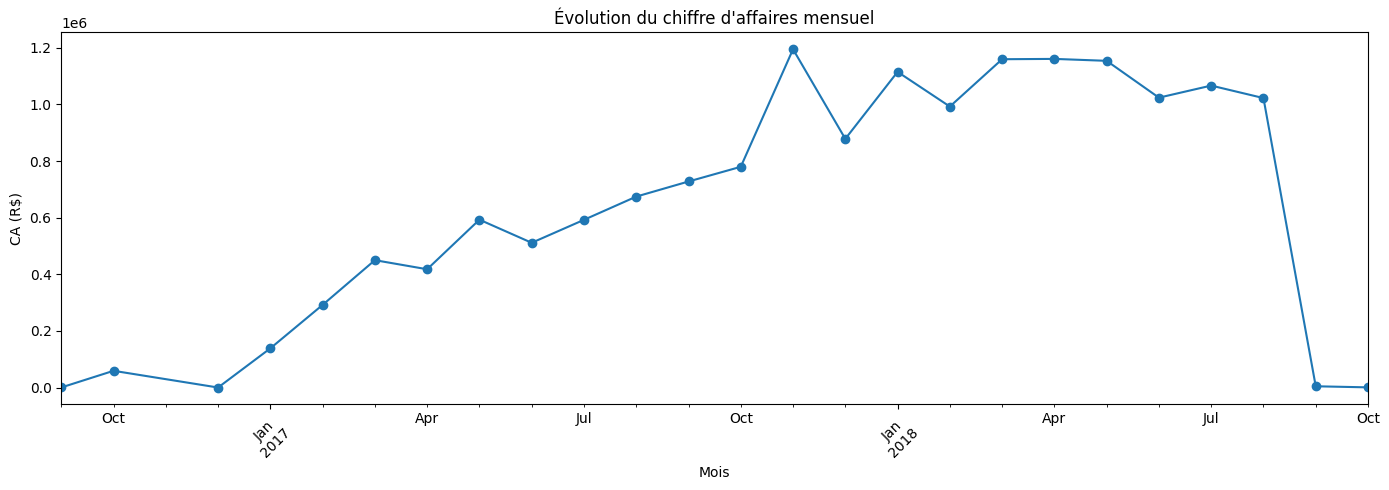

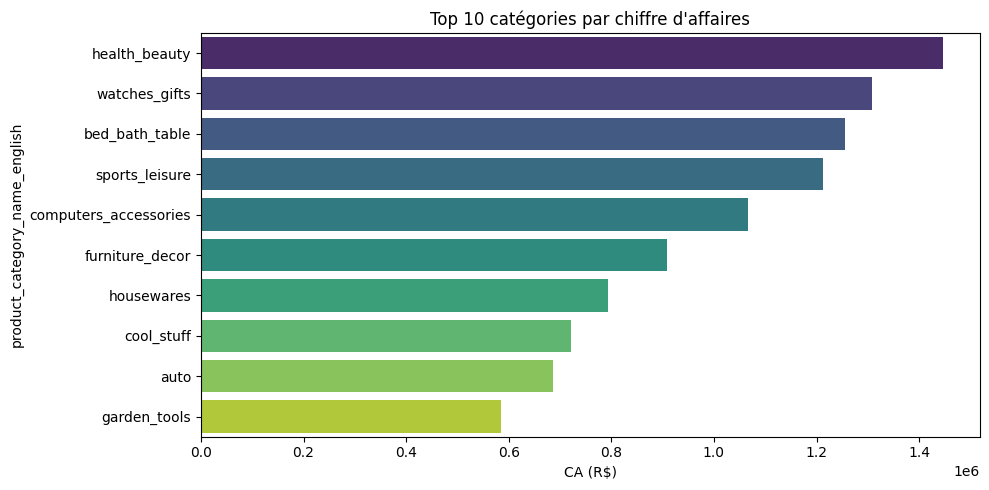

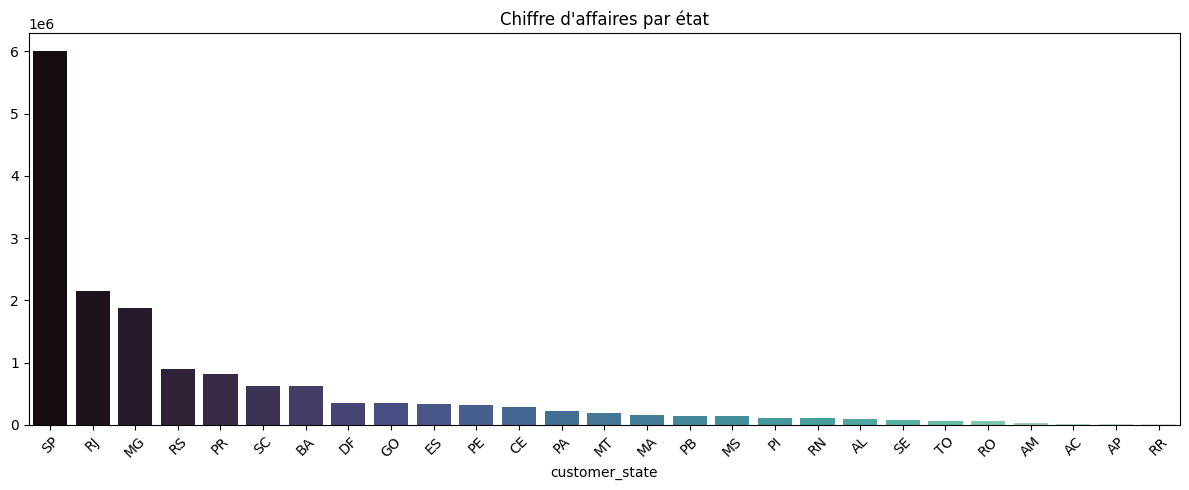

CA total : 16008872.120000001
Panier moyen : 160.98864774087147
Nombre de commandes : 99441


In [ ]:
fact_orders['order_purchase_timestamp'] = pd.to_datetime(fact_orders['order_purchase_timestamp'])
monthly_revenue = fact_orders.groupby(fact_orders['order_purchase_timestamp'].dt.to_period('M'))['total_payment_value'].sum()

plt.figure(figsize=(14, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title("Évolution du chiffre d'affaires mensuel")
plt.ylabel("CA (R$)"); plt.xlabel("Mois"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

top_categories = fact_order_items.groupby('product_category_name_english')['total_item_value'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette='viridis', legend=False)
plt.title("Top 10 catégories par chiffre d'affaires"); plt.xlabel("CA (R$)"); plt.tight_layout(); plt.show()

sales_by_state = fact_orders.groupby('customer_state')['total_payment_value'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=sales_by_state.index, y=sales_by_state.values, hue=sales_by_state.index, palette='mako', legend=False)
plt.title("Chiffre d'affaires par état"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print("CA total :", fact_orders['total_payment_value'].sum())
print("Panier moyen :", fact_orders['total_payment_value'].mean())
print("Nombre de commandes :", fact_orders.shape[0])


L'analyse montre une forte croissance commerciale entre fin 2016 et fin 2017, marquée par un pic exceptionnel en novembre 2017 (près de 1,2 million de R), suivie d'une stabilisation du chiffre d'affaires à un niveau élevé (~1 à 1,15 million de R) sur la majeure partie de l'année 2018, avant un arrêt brutal des enregistrements à l'automne (indiquant très probablement une fin de collecte de données). Cette performance financière globale repose essentiellement sur un noyau restreint de catégories vedettes : la section **health_beauty** s'impose comme le premier moteur de ventes avec environ 1,44 million de R, immédiatement suivie par **watches_gifts**, **bed_bath_table** et **sports_leisure**.

L'analyse de la répartition géographique révèle une hyper-concentration de l'activité commerciale dans la région Sud-Est du Brésil, menée de façon écrasante par l'état de **São Paulo (SP)** qui génère à lui seul environ 6 millions de R, soit plus d'un tiers du chiffre d'affaires total (16,01 millions de R). Les états de **Rio de Janeiro (RJ)** et **Minas Gerais (MG)** complètent ce podium stratégique avec respectivement 2,1 millions et 1,9 million de R. L'ensemble de l'activité s'appuie sur **99 441 commandes** pour un **panier moyen de 160,99 R**, avec une contribution marginale des autres états qui chute très rapidement après le top 3.

### 6.2 Analyse des clients (comportement, rétention, RFM)

Clients uniques : 96096
Clients ayant commandé plus d'une fois : 2997 (3.12%)


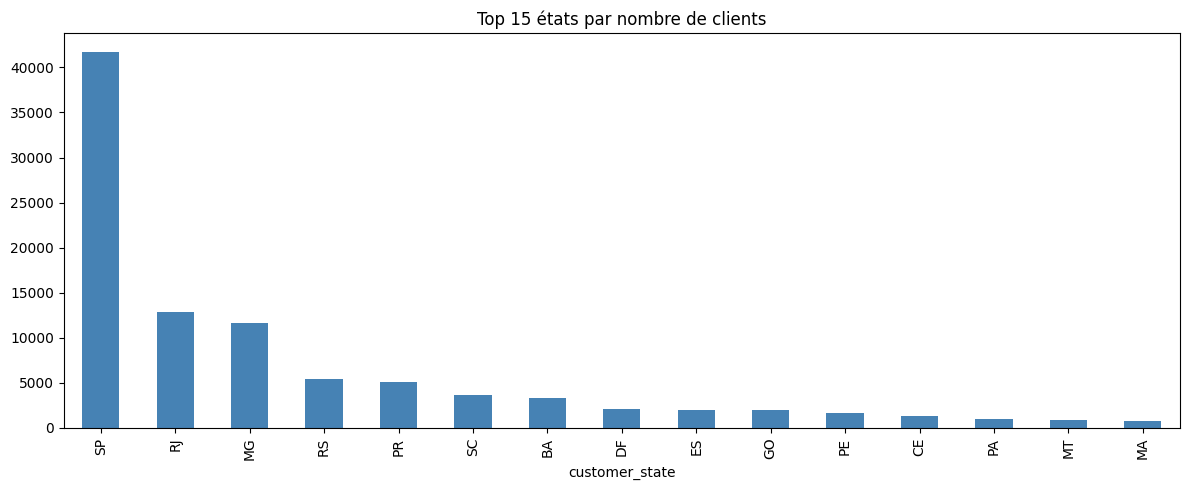

        recency  frequency  monetary
count 96,096.00  96,096.00 96,096.00
mean     288.74       1.03    166.59
std      153.41       0.21    231.43
min        1.00       1.00      0.00
25%      164.00       1.00     63.12
50%      269.00       1.00    108.00
75%      398.00       1.00    183.53
max      773.00      17.00 13,664.08
segment
12    6244
22    6205
43    6187
44    6158
11    6138
33    6137
34    6048
31    6006
23    5985
41    5951
Name: count, dtype: int64


In [ ]:
orders_customers = fact_orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
order_freq = orders_customers.groupby('customer_unique_id')['order_id'].count().sort_values(ascending=False)

print(f"Clients uniques : {orders_customers['customer_unique_id'].nunique()}")
print(f"Clients ayant commandé plus d'une fois : {(order_freq > 1).sum()} ({(order_freq > 1).mean() * 100:.2f}%)")


plt.figure(figsize=(12, 5))
customers['customer_state'].value_counts().head(15).plot(kind='bar', color='steelblue')
plt.title("Top 15 états par nombre de clients"); plt.tight_layout(); plt.show()

snapshot_date = fact_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm = orders_customers.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'count'), monetary=('total_payment_value', 'sum')
).reset_index()
print(rfm.describe())

rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])
rfm['segment'] = rfm['R_score'].astype(str) + rfm['M_score'].astype(str)
print(rfm['segment'].value_counts().head(10))
# NB : segments assez équilibrés (~6000 clients chacun), attendu avec un
# découpage par quartile ; sert de base de features pour une future
# classification client plus poussée si le temps du stage le permet.

L'analyse RFM et démographique basée sur **96 096 clients uniques** met en évidence un modèle fortement axé sur l'acquisition ponctuelle plutôt que la rétention, avec seulement **3,12 % de clients récurrents** (soit 2 997 clients et une fréquence moyenne de 1,03 achat). La valeur monétaire moyenne par client s'établit à **166,59 R** (médiane à 108 R, avec des valeurs extrêmes atteignant 13 664 R) pour une récence moyenne de **288,7 jours**. Géographiquement, la concentration reste maximale dans l'état de **São Paulo (SP)** avec plus de 40 000 clients, très loin devant **Rio de Janeiro (RJ)** (13 000) et **Minas Gerais (MG)** (11 500), tandis que le découpage par segments (scores RF) montre une répartition parfaitement homogène de la base de données (~6 000 clients par sous-groupe).

### 6.3 Analyse financière

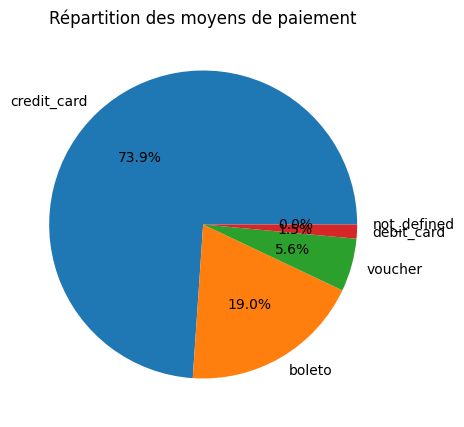

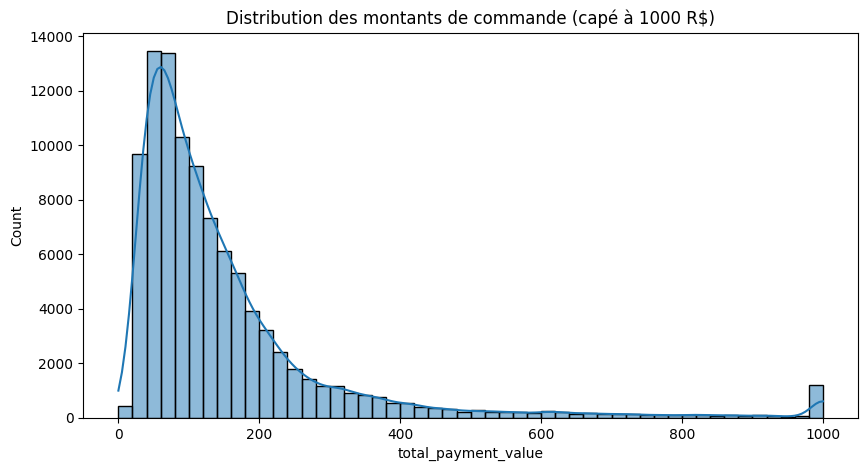

Marge estimée moyenne par item : 100.66341908566356


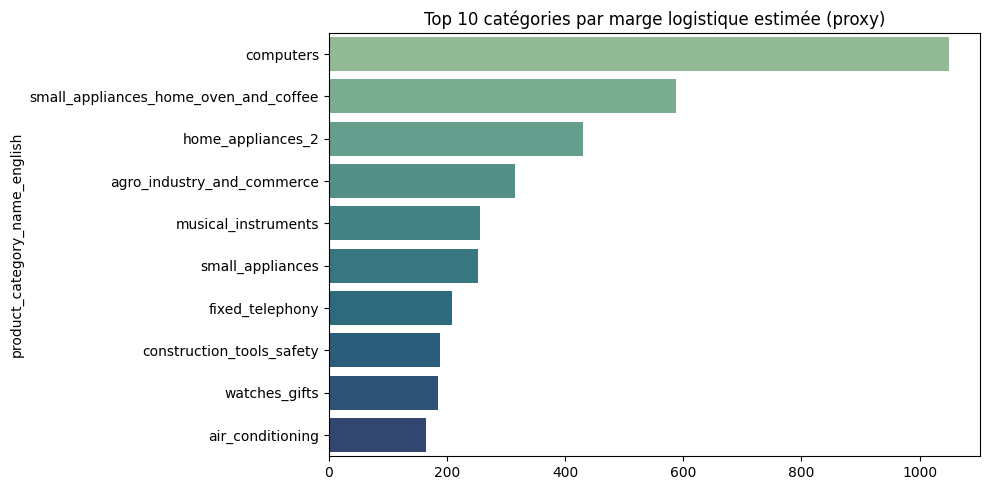

Ratio fret/prix médian : 0.23135623826460017


In [ ]:
plt.figure(figsize=(8, 5))
payments['payment_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Répartition des moyens de paiement"); plt.ylabel(""); plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(fact_orders['total_payment_value'].clip(upper=1000), bins=50, kde=True)
plt.title("Distribution des montants de commande (capé à 1000 R$)"); plt.show()

print("Marge estimée moyenne par item :", fact_order_items['estimated_margin'].mean())
margin_by_category = fact_order_items.groupby('product_category_name_english')['estimated_margin'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=margin_by_category.values, y=margin_by_category.index, hue=margin_by_category.index, palette='crest', legend=False)
plt.title("Top 10 catégories par marge logistique estimée (proxy)"); plt.tight_layout(); plt.show()

print("Ratio fret/prix médian :", fact_order_items['freight_ratio'].median())

L'analyse financière et comportementale indique une nette prédominance de la carte de crédit (**73,9 %**), suivie du **boleto** (**19,0 %**), pour des transactions majoritairement concentrées sur de petits montants (pic sous la barre des 100 à 200 R). La marge moyenne estimée par article s'élève à **100,66 R**, alors que les frais de livraison pèsent lourdement sur la valeur des commandes avec un ratio fret/prix médian de **23,14 %**. Enfin, la marge logistique reste portée par les équipements à forte valeur ajoutée : la catégorie **computers** domine très largement le classement (dépassant les 1 000 R), suivie par le petit et moyen électroménager (**small_appliances_home_oven_and_coffee** et **home_appliances_2**).

### 6.4 Corrélations entre variables

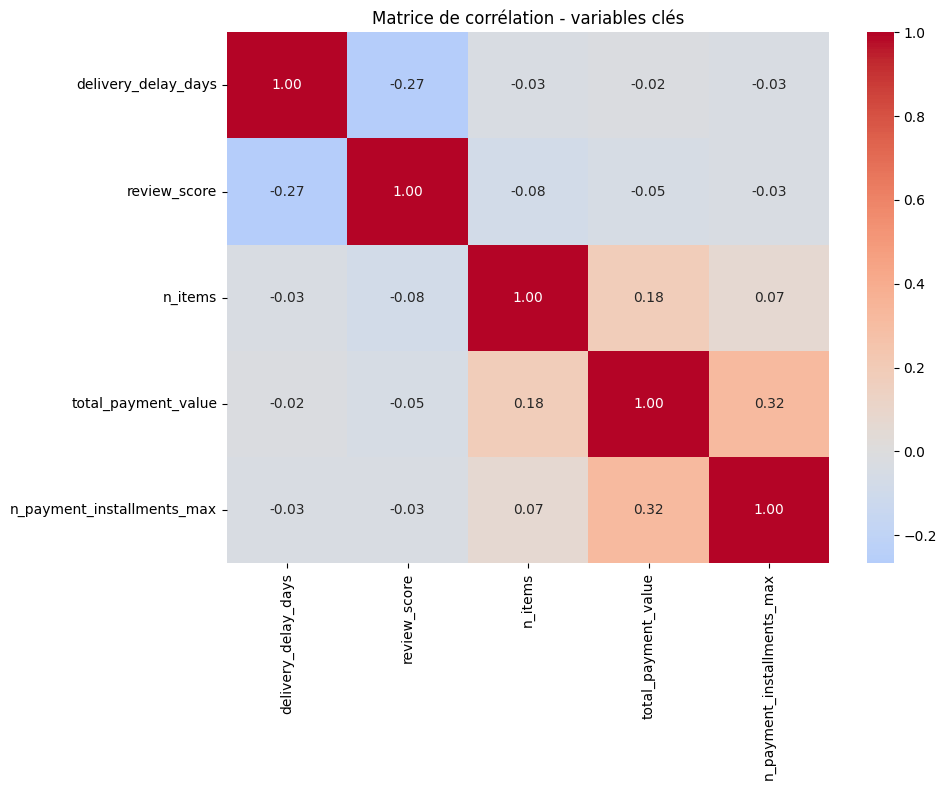

Corrélation délai de livraison / note review : -0.2666445100167465


In [ ]:
numeric_cols = ['price', 'freight_value', 'total_item_value', 'delivery_delay_days', 'review_score',
                 'n_items', 'total_payment_value', 'n_payment_installments_max']
corr_df = fact_orders[[c for c in numeric_cols if c in fact_orders.columns]].select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Matrice de corrélation - variables clés"); plt.tight_layout(); plt.show()

corr_delay_review = fact_orders[['delivery_delay_days', 'review_score']].corr().iloc[0, 1]
print("Corrélation délai de livraison / note review :", corr_delay_review)





STABLE_START, STABLE_END = '2017-01-01', '2018-08-31'

L'analyse des corrélations met en évidence deux relations clés : d'une part, le **retard de livraison pénalise la satisfaction client** avec une corrélation négative marquée de **-0,27** entre `delivery_delay_days` et `review_score`, confirmant la ponctualité logistique comme facteur critique de l'expérience utilisateur. D'autre part, le **montant de la commande est positivement lié au nombre de mensualités** (**0,32** entre `total_payment_value` et `n_payment_installments_max`), ce qui montre que les facilités de paiement par versements encouragent les paniers plus élevés. Enfin, les autres variables (nombre d'articles ou montant total) n'ont qu'un impact marginal sur la note attribuée par le client.

**Retard de livraison** — un diagnostic opérationnel immédiat, avec
   comparaison de 4 familles d'algorithmes et une simulation de Monte Carlo
   pour quantifier le risque sur un lot de commandes (pas juste une commande
   isolée).

## SECTION 7 — MODÈLE DE RISQUE DE RETARD DE LIVRAISON

**Objectif** : identifier les facteurs qui augmentent le risque de retard et
quantifier ce risque sur un lot de commandes

Répondre à des questions comme :

Les commandes lourdes sont-elles plus souvent en retard ?
Les commandes provenant d'un autre État que celui du client sont-elles plus risquées ?
Le nombre de vendeurs influence-t-il les délais ?
Certains mois présentent-ils davantage de retards que d'autres ?

Pour répondre à ces questions, on construit un dataset où :

1 ligne = 1 commande

et non 1 ligne = 1 produit.

####**retard de livraison**

##**Enrichir fact_orders avec les features logistiques manquantes**

je fais ce modèle au niveau commande (fact_orders), pas item (fact_order_items).
Car — delivery_delay_days est calculé à partir des dates de la commande, donc il est identique pour tous les items d'une même commande dans fact_order_items ; l'utiliser tel quel donnerait un poids artificiellement plus fort aux commandes multi-produits (chaque ligne dupliquée = même retard compté plusieurs fois). Au niveau commande, chaque exemple est indépendant.

Problème : same_state_delivery n'existe qu'au niveau item (le vendeur est une info item-level). Il faut donc l'agréger avant de rejoindre fact_orders.


In [ ]:

# PRÉPARATION DU DATASET POUR LE MODÈLE DE RISQUE DE RETARD DE LIVRAISON

# Le dataset Olist contient une phase de lancement en 2016 avec très peu de
# commandes et quelques mois atypiques .
#
# Les derniers mois de 2018 sont également incomplets, ce qui peut fausser les
# statistiques et les modèles prédictifs.
#
# Pour travailler sur une période représentative et stable de l'activité,
# on conserve uniquement les commandes entre janvier 2017 et août 2018.

STABLE_START, STABLE_END = '2017-01-01', '2018-08-31'

# Filtrage sur la periode stable ET sur les commandes reellement livrees
# (is_late n'a de sens que pour une commande physiquement livree -- pour les
# 2680 commandes annulees/en cours/indisponibles, is_late est quand meme
# renseigne via une date de livraison ESTIMEE (delivery_date_imputed), ce
# qui fabriquerait un label sans observation reelle derriere).
fact_orders_stable = fact_orders[
    (fact_orders['order_purchase_timestamp'] >= STABLE_START) &
    (fact_orders['order_purchase_timestamp'] <= STABLE_END) &
    (fact_orders['order_status'] == 'delivered')
].copy()


# Obj
# Construire un dataset au niveau COMMANDE afin d'expliquer les retards de
# livraison.

# Pourquoi travailler au niveau commande ?

# Le retard de livraison (delivery_delay_days) est calculé à partir des dates
# de la commande :

#     date réelle de livraison - date estimée de livraison
#
# Ce retard est donc identique pour tous les produits appartenant à une même
# commande.
#
# Si l'on travaillait directement sur fact_order_items (niveau article),
# une commande contenant plusieurs produits apparaîtrait plusieurs fois avec
# exactement le même retard.

# Les commandes multi-produits seraient alors artificiellement surreprésentées
# dans le modèle.

# Pour éviter ce biais statistique, une commande doit correspondre à une seule
# observation dans le dataset d'apprentissage.


# AGRÉGATION DES VARIABLES LOGISTIQUES
# Certaines variables potentiellement explicatives du retard n'existent qu'au
# niveau article (fact_order_items).
# Exemples :
# - same_state_delivery :
#   indique si le vendeur se trouve dans le même État que le client.
# - product_weight_g :
#   poids du produit commandé.

# Comme le modèle travaille au niveau COMMANDE, ces informations doivent être
# agrégées avant d'être fusionnées avec fact_orders.

logistics_agg = fact_order_items.groupby('order_id').agg(

    # Proportion des articles provenant du même État que le client.

    pct_same_state=('same_state_delivery', 'mean'),

    # Poids moyen des produits composant la commande.
    avg_product_weight_g=('product_weight_g', 'mean'),

    # Poids du produit le plus lourd de la commande.
    max_product_weight_g=('product_weight_g', 'max')

).reset_index()


# ENRICHISSEMENT DE LA TABLE DES COMMANDES
# On fusionne les indicateurs logistiques calculés ci-dessus avec fact_orders.


delay_model_df = fact_orders_stable.merge(
    logistics_agg,
    on='order_id',
    how='left'
)


# CONTRÔLES DE QUALITÉ

print(f"Lignes disponibles : {len(delay_model_df)}")

# is_late = 1  → commande livrée après la date estimée
# is_late = 0  → commande livrée à temps ou en avance

print(
    f"Taux de retard global (is_late=1) : "
    f"{delay_model_df['is_late'].mean()*100:.1f}%"
)

Lignes disponibles : 96211
Taux de retard global (is_late=1) : 8.1%


Un taux de 7,9 % signifie que :

Environ 8 commandes sur 100
ont été livrées en retard.

Le retard de livraison est un événement relativement rare dans le dataset.

La majorité des commandes sont livrées dans les délais, ce qui est plutôt positif d'un point de vue logistique.

Cependant, les 7,9 % de commandes en retard représentent plusieurs milliers de cas et constituent précisément les situations que l'entreprise cherche à comprendre et à anticiper.
Les modèles prédictifs devront donc être évalués à l'aide de métriques adaptées telles que le F1-score et le recall de la classe « retard », plutôt qu'à travers la seule accuracy globale.

7.2 — Features et split

In [ ]:
# PRÉPARATION DES VARIABLES EXPLICATIVES DU MODÈLE DE RETARD
# ==============================================================================

# Objectif :
# Construire un dataset propre pour prédire si une commande sera livrée
# en retard (is_late = 1) ou à temps (is_late = 0).

# ==============================================================================
# VARIABLES EXPLICATIVES UTILISÉES
# ==============================================================================

# Ces variables décrivent :
#
# - la taille de la commande
# - le coût du transport
# - la complexité logistique
# - les caractéristiques des produits
# - les caractéristiques du client
# - la saisonnalité

delay_features = [

    # Valeur totale des produits de la commande
    'total_price',

    # Total des frais de livraison
    'total_freight',

    # Nombre d'articles dans la commande
    'n_items',

    # Nombre de produits différents
    'n_unique_products',

    # Nombre de vendeurs différents
    # (plus il y a de vendeurs, plus la logistique est complexe)
    'n_unique_sellers',

    # Pourcentage des produits expédiés depuis le même État que le client
    'pct_same_state',

    # Poids moyen des produits
    'avg_product_weight_g',

    # Produit le plus lourd de la commande
    'max_product_weight_g',

    # Nombre maximal d'échéances de paiement
    'n_payment_installments_max',

    # Présence d'un voucher (bon d'achat)
    'has_voucher',
]

# ENCODAGE DES VARIABLES CATÉGORIELLES


from sklearn.preprocessing import LabelEncoder

# Encodage de la catégorie principale du produit
# --------------------------------------------------------------------------


delay_model_df['main_category'] = (
    delay_model_df['main_category']
    .fillna('inconnue')
)

le_cat = LabelEncoder()

delay_model_df['category_enc'] = le_cat.fit_transform(
    delay_model_df['main_category']
)


delay_model_df['customer_state'] = (
    delay_model_df['customer_state']
    .fillna('inconnu')
)

le_state = LabelEncoder()

delay_model_df['state_enc'] = le_state.fit_transform(
    delay_model_df['customer_state']
)

# ==============================================================================
# FEATURE ENGINEERING TEMPOREL
# ==============================================================================

# Extraction du mois de la commande.
#
# Permet au modèle de détecter une éventuelle saisonnalité
# (Black Friday, Noël, vacances, etc.).

delay_model_df['order_month_num'] = (
    delay_model_df['order_purchase_timestamp']
    .dt.month
)

# Ajout des nouvelles variables à la liste des features
delay_features += [
    'category_enc',
    'state_enc',
    'order_month_num'
]

# ==============================================================================
# SUPPRESSION DES LIGNES INCOMPLÈTES
#On supprime  les commandes qui n'ont pas toutes les informations nécessaires.

delay_model = (
    delay_model_df
    .dropna(subset=delay_features + ['is_late'])
    .reset_index(drop=True)
)

print(f"Lignes après nettoyage : {len(delay_model)}")

# ==============================================================================
# SÉPARATION FEATURES / TARGET
# ==============================================================================

# X = variables explicatives
# y = variable à prédire

X = delay_model[delay_features]

# 1 = retard
# 0 = à temps
y = delay_model['is_late']

# ==============================================================================
# TRAIN / TEST SPLIT
# ==============================================================================

from sklearn.model_selection import train_test_split

# 80 % des données servent à entraîner le modèle
# 20 % servent à l'évaluer sur des données jamais vues

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(
    f"Train : {len(X_train)} | "
    f"Test : {len(X_test)} | "
    f"Taux retard train/test : "
    f"{y_train.mean()*100:.1f}% / "
    f"{y_test.mean()*100:.1f}%"
)

Lignes après nettoyage : 96211
Train : 76968 | Test : 19243 | Taux retard train/test : 8.1% / 8.1%


### 7.3 — Comparaison de 4 familles d'algorithmes

**Le critère de sélection reste le F1-score sur la classe "Retard"**, jamais
l'accuracy globale : avec seulement 8,1% de retards, un modèle qui ne prédit
jamais de retard aurait déjà ~92% d'accuracy sans être utile. Choisir le
modèle qui optimise le bon critère métier — pas celui qui a le nom le plus
impressionnant, ni celui qui maximise un chiffre trompeur

Modèle
Logistic Regression	modèle linéaire
Random Forest	ensemble d'arbres
SVM	séparation par frontière complexe
XGBoost	boosting d'arbres

on va utiliser balanced pour gerer le desequilibre

Ainsi on va utiliser F1 score métrique particulièrement adaptée aux problèmes de classification déséquilibrés. Le modèle obtenant le meilleur F1-score seraretenu pour l'analyse des facteurs explicatifs du retard de livraison.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

# LogReg et SVM sont sensibles a l'echelle des features (contrairement aux
# modeles a base d'arbres) -> standardisation dediee, meme principe que la
scaler_delay = StandardScaler()
X_train_scaled = scaler_delay.fit_transform(X_train)
X_test_scaled = scaler_delay.transform(X_test)

# XGBoost n'a pas de parametre class_weight='balanced' : on calcule
# l'equivalent (scale_pos_weight = ratio negatif/positif) pour compenser le
# desequilibre (8.1% de retards), meme logique que class_weight ailleurs.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models_delay = {
    "Logistic Regression": (
        "scaled",
        LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=42
        ),
    ),
    "Random Forest": (
        "raw",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
        ),
    ),
    "SVM (RBF)": (
        "scaled",
        SVC(
            kernel="rbf",
            C=1.0,
            class_weight="balanced",
            probability=True,
            random_state=42,
        ),
    ),
    "XGBoost Classifier": (
        "raw",
        XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric="logloss",
        ),
    ),
}

delay_results = {}
for name, (feat_type, model) in models_delay.items():
    Xtr = X_train_scaled if feat_type == "scaled" else X_train
    Xte = X_test_scaled if feat_type == "scaled" else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    f1 = f1_score(y_test, y_pred)
    delay_results[name] = {
        "model": model,
        "f1": f1,
        "y_pred": y_pred,
        "feat_type": feat_type,
    }
    print(f"\n=== {name} (F1 classe 'retard' = {f1:.3f}) ===")
    print(
        classification_report(
            y_test, y_pred, target_names=["A temps", "Retard"]
        )
    )

best_name = max(delay_results, key=lambda n: delay_results[n]["f1"])
best_delay_model = delay_results[best_name]["model"]
best_feat_type = delay_results[best_name]["feat_type"]
print(
    f"\n>>> Meilleur modele : {best_name} (F1 = {delay_results[best_name]['f1']:.3f})"
)


=== Logistic Regression (F1 classe 'retard' = 0.173) ===
              precision    recall  f1-score   support

     A temps       0.94      0.49      0.64     17679
      Retard       0.10      0.64      0.17      1564

    accuracy                           0.50     19243
   macro avg       0.52      0.56      0.41     19243
weighted avg       0.87      0.50      0.61     19243


=== Random Forest (F1 classe 'retard' = 0.259) ===
              precision    recall  f1-score   support

     A temps       0.95      0.77      0.85     17679
      Retard       0.17      0.54      0.26      1564

    accuracy                           0.75     19243
   macro avg       0.56      0.65      0.55     19243
weighted avg       0.89      0.75      0.80     19243


=== SVM (RBF) (F1 classe 'retard' = 0.221) ===
              precision    recall  f1-score   support

     A temps       0.95      0.70      0.80     17679
      Retard       0.14      0.55      0.22      1564

    accuracy            

Les résultats montrent que les quatre modèles arrivent à détecter une partie des retards, mais avec des performances limitées à cause du fort déséquilibre entre les classes. La **régression logistique** obtient le plus faible F1-score (**0.173**) : elle détecte 64% des retards (recall élevé) mais génère beaucoup de fausses alertes, avec une précision de seulement 10%. Le **SVM** améliore légèrement les résultats avec un F1-score de **0.221**. Le **Random Forest** (0.259) et le **XGBoost** (0.265) obtiennent des résultats quasiment identiques — un écart de 0,006, soit environ 2% relatif, trop faible pour conclure à une réelle supériorité d'une famille d'algorithme sur l'autre. XGBoost est retenu selon le critère strict (meilleur F1), mais Random Forest constitue une alternative tout aussi défendable : les deux captent le même signal dominant (voir l'importance par permutation ci-dessous).

,model,F1_retard
3,XGBoost Classifier,0.26
1,Random Forest,0.26
2,SVM (RBF),0.22
0,Logistic Regression,0.17


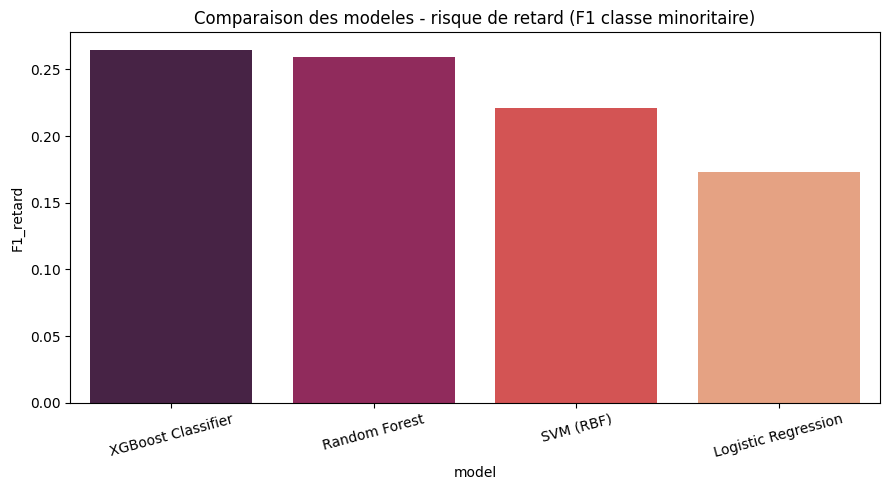

In [ ]:
delay_comparison_df = pd.DataFrame([
    {"model": name, "F1_retard": r["f1"]} for name, r in delay_results.items()
]).sort_values("F1_retard", ascending=False)
display(delay_comparison_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=delay_comparison_df, x="model", y="F1_retard", hue="model", legend=False, palette="rocket")
plt.title("Comparaison des modeles - risque de retard (F1 classe minoritaire)")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()


Random Forest et XGBoost obtiennent des résultats quasiment équivalents (F1 ≈ 0.26), ce qui indique qu'ils captent le même signal utile, contrairement à Logistic Regression et SVM, nettement en retrait. XGBoost est retenu comme modèle final car il obtient le meilleur F1-score (0.265) parmi les 4 modèles testés — un écart faible avec Random Forest (0.259), à interpréter avec prudence plutôt que comme une victoire décisive.

### 7.4 — Explication du modèle retenu

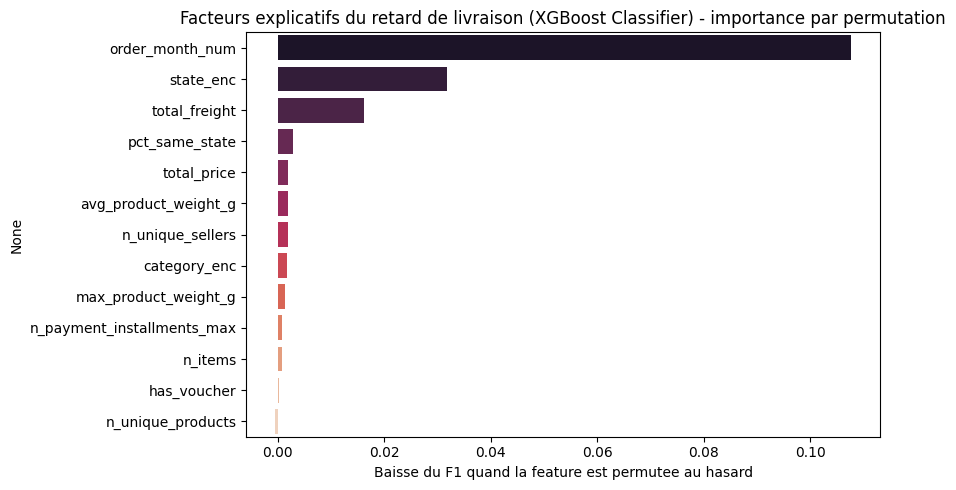

order_month_num               0.11
state_enc                     0.03
total_freight                 0.02
pct_same_state                0.00
total_price                   0.00
avg_product_weight_g          0.00
n_unique_sellers              0.00
category_enc                  0.00
max_product_weight_g          0.00
n_payment_installments_max    0.00
n_items                       0.00
has_voucher                   0.00
n_unique_products            -0.00
dtype: float64


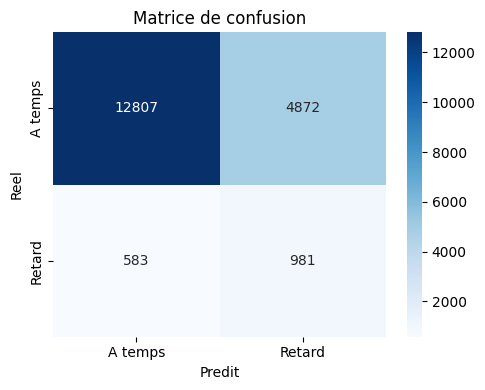

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance

Xte_best = X_test_scaled if best_feat_type == "scaled" else X_test
perm = permutation_importance(best_delay_model, Xte_best, y_test, n_repeats=20,
                               random_state=42, scoring='f1')
importances = pd.Series(perm.importances_mean, index=delay_features).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='rocket', legend=False)
plt.title(f"Facteurs explicatifs du retard de livraison ({best_name}) - importance par permutation")
plt.xlabel("Baisse du F1 quand la feature est permutee au hasard")
plt.tight_layout(); plt.show()
print(importances)

cm = confusion_matrix(y_test, delay_results[best_name]['y_pred'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['A temps','Retard'], yticklabels=['A temps','Retard'])
plt.title("Matrice de confusion"); plt.ylabel("Reel"); plt.xlabel("Predit"); plt.tight_layout(); plt.show()


Les résultats indiquent que les facteurs temporels (order_month_num, saisonnalité) et géographiques (state_enc, pct_same_state) sont les principaux déterminants du risque de retard de livraison dans le dataset Olist, tandis que les caractéristiques de la commande et des produits ont un impact beaucoup plus limité.

La matrice de confusion du modèle XGBoost montre que 12 807 commandes ont été correctement classées comme livrées à temps et 981 retards ont été correctement détectés. Le modèle manque 583 retards réels (faux négatifs) et génère 4 872 fausses alertes (faux positifs). Ainsi, il parvient à identifier environ 63% des commandes en retard (recall = 63%), mais la précision reste faible (17%) : une grande partie des commandes signalées comme à risque sont finalement livrées dans les délais.

Ces résultats reflètent la difficulté de prédire un événement rare représentant seulement 8,1% des observations du dataset. Comparé au Random Forest testé précédemment (recall 54%, précision 17%), XGBoost détecte davantage de retards réels pour une précision quasi identique — c'est ce compromis légèrement meilleur, plus que le F1-score seul, qui justifie son choix comme modèle final.

Les modèles ont été entraînés avec un rééquilibrage des classes afin d'améliorer la détection des retards. Cette stratégie peut toutefois biaiser les probabilités retournées par predict_proba(). Une étape de calibration des probabilités a donc été appliquée à l'aide de CalibratedClassifierCV (méthode sigmoïde). Cette calibration ne modifie pas les performances de classification du modèle mais permet d'obtenir des probabilités plus fidèles au risque réel observé, rendant les prédictions exploitables pour des analyses et prises de décision métier.

In [ ]:
# ==============================================================================
# CALIBRATION DES PROBABILITES (necessaire avant la simulation ci-dessous)
# ==============================================================================
# class_weight='balanced' (utilise pour bien detecter la classe rare) deforme
# les probabilites predites : predict_proba() ne reflete alors plus le vrai
# risque, seulement un score utile pour CLASSER les commandes entre elles.
# CalibratedClassifierCV corrige cela a posteriori, sans toucher au F1-score
# ni au choix du meilleur modele
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

Xtr_best = X_train_scaled if best_feat_type == "scaled" else X_train

calibrated_delay_model = CalibratedClassifierCV(clone(best_delay_model), method='sigmoid', cv=5)
calibrated_delay_model.fit(Xtr_best, y_train)

raw_mean = best_delay_model.predict_proba(Xte_best)[:, 1].mean() * 100
calibrated_mean = calibrated_delay_model.predict_proba(Xte_best)[:, 1].mean() * 100
print(f"Probabilite moyenne AVANT calibration : {raw_mean:.1f}%")
print(f"Probabilite moyenne APRES calibration  : {calibrated_mean:.1f}%  (vrai taux observe : {y_test.mean()*100:.1f}%)")

Probabilite moyenne AVANT calibration : 43.1%
Probabilite moyenne APRES calibration  : 8.2%  (vrai taux observe : 8.1%)


Une simulation de Monte Carlo a été réalisée à partir des probabilités de retard prédites par le modèle.

Chaque commande est considérée comme un événement aléatoire dont la probabilité de retard est donnée par le modèle.

En répétant 10 000 simulations, il est possible d'obtenir une distribution du nombre total de retards attendus sur un lot de commandes similaire.

Cette approche fournit non seulement une estimation centrale du nombre de retards, mais également un intervalle d'incertitude, permettant d'évaluer différents scénarios logistiques et d'améliorer la planification opérationnelle.

Lot simule : 19243 commandes (jeu de test, proxy d'un lot futur)
Probabilite de retard moyenne du lot : 8.2%

Nombre de retards attendus sur ce lot de 19243 commandes :
  P10 = 1522 | Mediane = 1569 | P90 = 1615
  (80% de chances que le nombre reel de retards tombe dans [1522 ; 1615])


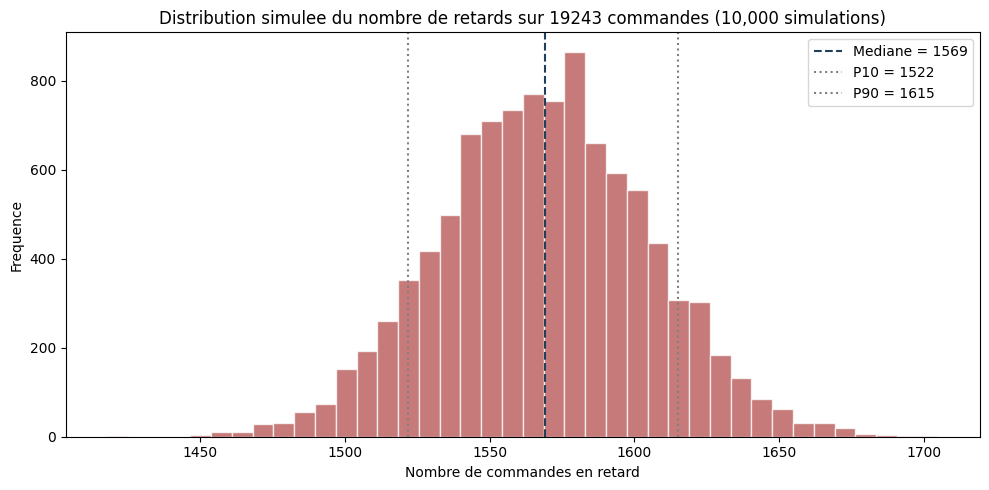

In [ ]:
np.random.seed(42)
#On répète l'expérience 10 000 fois afin d'obtenir une distribution réaliste
#du nombre total de retards possibles sur un lot de commandes.
#Chaque simulation répond à la question :
#"Si un lot similaire arrivait demain, combien de retards pourrait-on observer ?"

N_MC_DELAY = 10000

Xte_probs_input = X_test_scaled if best_feat_type == "scaled" else X_test
batch_probs = calibrated_delay_model.predict_proba(Xte_probs_input)[:, 1]
n_orders_batch = len(batch_probs)
print(f"Lot simule : {n_orders_batch} commandes (jeu de test, proxy d'un lot futur)")
print(f"Probabilite de retard moyenne du lot : {batch_probs.mean()*100:.1f}%")

# Tirage de Bernoulli INDEPENDANT par commande, repete N_MC_DELAY fois
#effectue un tirage de Bernoulli pour chaque commande :
#1 = retard
#0 = pas de retard
#avec la probabilité prédite par le modèle.

simulated_late_counts = np.random.binomial(1, batch_probs, size=(N_MC_DELAY, n_orders_batch)).sum(axis=1)

p10, median, p90 = np.percentile(simulated_late_counts, [10, 50, 90])
print(f"\nNombre de retards attendus sur ce lot de {n_orders_batch} commandes :")
print(f"  P10 = {p10:.0f} | Mediane = {median:.0f} | P90 = {p90:.0f}")
print(f"  (80% de chances que le nombre reel de retards tombe dans [{p10:.0f} ; {p90:.0f}])")

plt.figure(figsize=(10, 5))
plt.hist(simulated_late_counts, bins=40, color='#B34D4D', alpha=0.75, edgecolor='white')
plt.axvline(median, color='#1F3F5C', linestyle='--', label=f'Mediane = {median:.0f}')
plt.axvline(p10, color='gray', linestyle=':', label=f'P10 = {p10:.0f}')
plt.axvline(p90, color='gray', linestyle=':', label=f'P90 = {p90:.0f}')
plt.title(f"Distribution simulee du nombre de retards sur {n_orders_batch} commandes ({N_MC_DELAY:,} simulations)")
plt.xlabel("Nombre de commandes en retard"); plt.ylabel("Frequence")
plt.legend(); plt.tight_layout(); plt.show()


Le Service Après-Vente (SAV) et l'équipe logistique doivent anticiper la gestion d'environ 1 569 réclamations ou tickets de suivi pour ce volume de livraisons (19 243 commandes simulées).

En prévoyant une capacité opérationnelle maximale de 1 615 retards (scénario défavorable à 90%), l'entreprise couvre la quasi-totalité des aléas statistiques sans surdimensionner inutilement ses ressources.

P10 (scénario optimiste, 1 522 retards) : seulement 10% de chances que les livraisons se passent assez bien pour descendre sous ce seuil.
P90 (scénario pessimiste/sécurité, 1 615 retards) : 90% de chances que le nombre de retards ne dépasse pas ce seuil.

L'écart entre P10 et P90 (93 commandes, ~6% du volume) reste étroit — la distribution resserrée confirme une bonne prédictibilité pour le pilotage opérationnel.

In [ ]:
import joblib
joblib.dump(best_delay_model, '/content/model_delivery_delay.pkl')
joblib.dump(le_cat, '/content/label_encoder_category.pkl')
joblib.dump(le_state, '/content/label_encoder_state.pkl')
joblib.dump(delay_features, '/content/delay_model_features.pkl')

from google.colab import files
files.download('/content/model_delivery_delay.pkl')
files.download('/content/label_encoder_category.pkl')
files.download('/content/label_encoder_state.pkl')
files.download('/content/delay_model_features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
from google.colab import files

# Sauvegarde et téléchargement du modèle calibré uniquement
joblib.dump(calibrated_delay_model, '/content/model_delivery_delay_calibrated.pkl')
files.download('/content/model_delivery_delay_calibrated.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

print("==================================================")
print("  SAISIE INTERACTIVE DES FEATURES DE LA COMMANDE  ")
print("==================================================\n")

# Dictionnaire pour stocker les saisies utilisateur
saisie = {}

# Saisie guidée champ par champ
saisie["total_price"] = float(
    input("1/13 - Prix total des produits (€) [ex: 150.0] : ")
)
saisie["total_freight"] = float(
    input("2/13 - Frais de livraison (€) [ex: 25.0] : ")
)
saisie["n_items"] = int(
    input("3/13 - Nombre total d'articles dans la commande [ex: 2] : ")
)
saisie["n_unique_products"] = int(
    input("4/13 - Nombre de produits différents [ex: 1] : ")
)
saisie["n_unique_sellers"] = int(
    input("5/13 - Nombre de vendeurs différents [ex: 1] : ")
)
saisie["pct_same_state"] = float(
    input("6/13 - Part d'articles expédiés du même État (0.0 à 1.0) : ")
)
saisie["avg_product_weight_g"] = float(
    input("7/13 - Poids moyen des produits en grammes [ex: 1200] : ")
)
saisie["max_product_weight_g"] = float(
    input("8/13 - Poids du produit le plus lourd (g) [ex: 2000] : ")
)
saisie["n_payment_installments_max"] = int(
    input("9/13 - Nombre maximal d'échéances de paiement [ex: 3] : ")
)
saisie["has_voucher"] = int(
    input("10/13 - Présence d'un bon d'achat/voucher (0 ou 1) : ")
)
saisie["main_category"] = input(
    "11/13 - Nom de la catégorie principale [ex: cama_mesa_banho] : "
).strip()
saisie["customer_state"] = (
    input("12/13 - État du client (2 lettres) [ex: SP, RJ, MG] : ")
    .strip()
    .upper()
)
saisie["order_month_num"] = int(
    input("13/13 - Mois de la commande (1 à 12) [ex: 11] : ")
)

# Traitement DataFrame & Encodage
df_saisie = pd.DataFrame([saisie])


def encode_safe(encoder, val):
    return (
        encoder.transform([val])[0]
        if val in encoder.classes_
        else encoder.transform([encoder.classes_[0]])[0]
    )


df_saisie["category_enc"] = encode_safe(le_cat, saisie["main_category"])
df_saisie["state_enc"] = encode_safe(le_state, saisie["customer_state"])

# Préparation du vecteur de features
X_saisie = df_saisie[delay_features]

if best_feat_type == "scaled":
    X_input_final = scaler_delay.transform(X_saisie)
else:
    X_input_final = X_saisie.values

# Calcul de la prédiction et de la probabilité calibrée
prob_retard = calibrated_delay_model.predict_proba(X_input_final)[0, 1]
target_predite = int(prob_retard >= 0.5)
f1_modele = delay_results[best_name]["f1"]

# Affichage du résultat final
print("\n" + "=" * 55)
print("             RÉSULTAT DE LA PRÉDICTION             ")
print("=" * 55)
print(f"• Modèle évalué          : {best_name}")
print(f"• F1-Score du modèle     : {f1_modele:.3f}")
print(f"• Probabilité de retard  : {prob_retard * 100:.2f}%")
print(
    f"• Target prédite (is_late): {target_predite} "
    f"({'⚠️ EN RETARD' if target_predite == 1 else '✅ À TEMPS'})"
)
print("=" * 55)

  SAISIE INTERACTIVE DES FEATURES DE LA COMMANDE  

1/13 - Prix total des produits (€) [ex: 150.0] : 120
2/13 - Frais de livraison (€) [ex: 25.0] : 24
3/13 - Nombre total d'articles dans la commande [ex: 2] : 4
4/13 - Nombre de produits différents [ex: 1] : 1
5/13 - Nombre de vendeurs différents [ex: 1] : 1
6/13 - Part d'articles expédiés du même État (0.0 à 1.0) : 0
7/13 - Poids moyen des produits en grammes [ex: 1200] : 1000
8/13 - Poids du produit le plus lourd (g) [ex: 2000] : 500
9/13 - Nombre maximal d'échéances de paiement [ex: 3] : 2
10/13 - Présence d'un bon d'achat/voucher (0 ou 1) : 0
11/13 - Nom de la catégorie principale [ex: cama_mesa_banho] : cama_mesa_banho
12/13 - État du client (2 lettres) [ex: SP, RJ, MG] : SP
13/13 - Mois de la commande (1 à 12) [ex: 11] : 9

             RÉSULTAT DE LA PRÉDICTION             
• Modèle évalué          : Random Forest
• F1-Score du modèle     : 0.259
• Probabilité de retard  : 3.68%
• Target prédite (is_late): 0 (✅ À TEMPS)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## SECTION 8 — PRÉVISION DU CHIFFRE D'AFFAIRES PAR CATÉGORIE ET RÉGION

**Ce que ce modèle prédit, exactement** : le CA du mois prochain, PAR
catégorie de produit et PAR état client — répond à des questions
actionnables (*quelle catégorie va tirer la croissance, dans quelle
région ?*), contrairement au baromètre hebdomadaire global de la dernière
section.

**Approche retenue : top-down.** Un modèle par combinaison (catégorie ×
état) serait entraîné sur une poignée de points chacun — intenable. On
prédit donc (1) le CA par catégorie (grain assez peuplé pour des lags
fiables), puis (2) on répartit ce CA par état via sa part historique dans
cette catégorie.


In [ ]:
# PREVISION DU CHIFFRE D'AFFAIRES PAR CATEGORIE ET PAR REGION (APPROCHE TOP-DOWN)

# Obj
# Construire une série temporelle de chiffre d'affaires par catégorie
# de produits afin de prévoir les ventes futures.

# L'approche "Top-Down":
# 1. On prédit d'abord le CA global ou le CA par catégorie.
# 2. Ensuite on peut répartir ces prévisions selon les régions.

# Cette approche est généralement plus robuste que de prévoir directement
# le CA de chaque région séparément lorsque certaines régions ont peu
# d'observations.

# ETAPE 1 : SELECTION DE LA PERIODE STABLE

# Les premiers mois de 2016 correspondent à la phase de lancement
# d'Olist avec peu de commandes.Ainsi les derniers mois de 2018 sont incomplets.

# Pour éviter d'introduire du bruit dans les modèles de prévision,
# on conserve uniquement la période d'activité stable.

STABLE_START = '2017-01-01'
STABLE_END   = '2018-08-31'

items_stable = fact_order_items[
    (fact_order_items['order_purchase_timestamp'] >= STABLE_START) &
    (fact_order_items['order_purchase_timestamp'] <= STABLE_END)
].copy()

# ETAPE 2 : CONSTRUCTION DE LA SERIE TEMPORELLE

# Grain choisi : Catégorie × Mois
# Chaque ligne représente donc :
# une catégorie pour un mois donné avec son chiffre d'affaires total


category_monthly = (

    items_stable

    # Transformation de la date d'achat en index temporel
    .set_index('order_purchase_timestamp')

    # Regroupement par catégorie produit
    .groupby('product_category_name_english')

    # Agrégation mensuelle
    .resample('MS')['total_item_value']

    # Somme du CA du mois
    .sum()

    .reset_index()

    .rename(
        columns={
            'order_purchase_timestamp': 'month',
            'total_item_value': 'revenue'
        }
    )
)

# ETAPE 3 : ANALYSE DE LA COUVERTURE TEMPORELLE


# Avant de construire un modèle de prévision,
# il faut vérifier que chaque catégorie possède suffisamment
# d'historique.
##il y a des catégories disposent d'un historique régulier et sont donc de
# bonnes candidates pour la prévision.
#À l'inverse, les catégories n'ayant vendu que pendant quelques mois ne possèdent
#pas assez d'information pour qu'un modèle puisse apprendre une tendance fiable.


#
# On calcule donc :
#Nombre de mois où le CA est strictement positif.

coverage = (
    category_monthly
    .groupby('product_category_name_english')['revenue']
    .apply(lambda s: (s > 0).sum())
    .sort_values(ascending=False)
)


# DIAGNOSTICS
# Nombre total de catégories

print(f"Nombre de catégories : {coverage.shape[0]}")

# Nombre de mois présents dans la période étudiée

print(
    f"Nombre de mois dans la fenêtre stable : "
    f"{category_monthly['month'].nunique()}"
)

# Statistiques descriptives de couverture

print("\nCouverture (nombre de mois avec CA > 0) :")
print(coverage.describe())

# Catégories les plus régulières

print("\nTop 10 catégories les mieux couvertes :")
print(coverage.head(10))

# Catégories les plus irrégulières

print("\n10 catégories les moins couvertes :")
print(coverage.tail(10))

Nombre de catégories : 71
Nombre de mois dans la fenêtre stable : 20

Couverture (nombre de mois avec CA > 0) :
count   71.00
mean    17.15
std      4.28
min      2.00
25%     15.00
50%     19.00
75%     20.00
max     20.00
Name: revenue, dtype: float64

Top 10 catégories les mieux couvertes :
product_category_name_english
air_conditioning          20
auto                      20
baby                      20
computers_accessories     20
consoles_games            20
books_general_interest    20
bed_bath_table            20
musical_instruments       20
office_furniture          20
pet_shop                  20
Name: revenue, dtype: int64

10 catégories les moins couvertes :
product_category_name_english
party_supplies                           12
small_appliances_home_oven_and_coffee    11
furniture_mattress_and_upholstery        11
la_cuisine                                9
diapers_and_hygiene                       9
flowers                                   9
fashion_childrens_clothes 

L'analyse de couverture montre que les **71 catégories de produits** disposent globalement d'un historique suffisant pour la prévision, avec une moyenne de **17 mois actifs sur les 20 mois** de la période étudiée. La moitié des catégories sont présentes au moins **19 mois**, ce qui traduit une activité relativement régulière. Plusieurs catégories majeures, telles que *bed_bath_table*, *auto* ou *computers_accessories*, sont actives sur l'ensemble des **20 mois**, ce qui en fait de bonnes candidates pour la modélisation. En revanche, certaines catégories présentent une couverture très limitée, comme *security_and_services* (2 mois), *cds_dvds_musicals* (6 mois) ou *flowers* (9 mois), ce qui rend leurs séries temporelles peu fiables pour l'apprentissage. Ces résultats justifient le regroupement des catégories les moins représentées dans une catégorie **« Autres »**, afin d'améliorer la robustesse des modèles de prévision.


In [ ]:

# REGROUPEMENT DES PETITES CATEGORIES

# Certaines catégories apparaissent très rarement dans l'historique.
# Une série temporelle trop courte ne permet pas d'apprendre des tendances
# fiables.
#
# Exemple :
# - Catégorie A : ventes sur 20 mois
# - Catégorie B : ventes sur seulement 3 mois
#
# La catégorie B contient trop peu d'information pour entraîner un modèle
# robuste.
#
# On décide donc de regrouper toutes les catégories présentes moins de
# 12 mois dans une catégorie unique appelée "Autres".


MIN_COVERAGE_MONTHS = 12

small_categories = coverage[
    coverage < MIN_COVERAGE_MONTHS
].index.tolist()

print(
    f"{len(small_categories)} catégories regroupées en 'Autres' : "
    f"{small_categories}"
)

# Remplacement des catégories peu représentées par "Autres"

category_monthly['category_grouped'] = (
    category_monthly['product_category_name_english']
    .apply(
        lambda c: 'Autres'
        if c in small_categories
        else c
    )
)

# REAGREGATION APRES REGROUPEMENT

#
# Après avoir renommé plusieurs catégories en "Autres",
# il faut recalculer le chiffre d'affaires.
# On somme donc les revenus par mois.


cat_monthly_grouped = (

    category_monthly

    .groupby(
        ['category_grouped', 'month']
    )['revenue']

    .sum()

    .reset_index()
)

# CREATION D'UNE GRILLE COMPLETE CATEGORIE × MOIS

# Certaines catégories n'ont réalisé aucune vente sur certains mois.
# Sans cette étape, ces mois seraient absents du dataset.
# Exemple :

# Beauty :
# Janvier
# Mars
# Avril

# Février disparaîtrait.
#
# Les variables temporelles (lag) seraient alors fausses.
#
# On crée donc toutes les combinaisons possibles :
#
# Catégorie × Mois
#
# afin de conserver explicitement les mois sans ventes.


all_months = (
    cat_monthly_grouped['month']
    .sort_values()
    .unique()
)

all_cats = (
    cat_monthly_grouped['category_grouped']
    .unique()
)

full_grid = (

    pd.MultiIndex

    .from_product(
        [all_cats, all_months],
        names=[
            'category_grouped',
            'month'
        ]
    )

    .to_frame(index=False)
)

# AJOUT DES DONNEES DE CA A LA GRILLE COMPLETE
#
# Les combinaisons absentes correspondent à des mois où le CA est nul.
#
# Elles seront remplacées par 0.


cat_monthly_full = (

    full_grid

    .merge(
        cat_monthly_grouped,
        on=[
            'category_grouped',
            'month'
        ],
        how='left'
    )
)

cat_monthly_full['revenue'] = (
    cat_monthly_full['revenue']
    .fillna(0)
)

cat_monthly_full = (

    cat_monthly_full

    .sort_values(
        ['category_grouped', 'month']
    )

    .reset_index(drop=True)
)


# FEATURE ENGINEERING TEMPOREL

# Création de variables permettant au modèle d'apprendre :

# - les tendances
# - la saisonnalité
# - la mémoire des ventes passées


# INDEX TEMPOREL
#
# Numéro du mois depuis le début de la série.

# Exemple :
#
# Jan 2017 -> 0
# Fev 2017 -> 1
# Mars 2017 -> 2
#
# Permet au modèle de détecter une tendance générale.

cat_monthly_full['month_index'] = (

    cat_monthly_full

    .groupby('category_grouped')

    .cumcount()
)


# MOIS DE L'ANNEE

# Permet de capturer la saisonnalité :
#
# - Noël
# - Black Friday
# - vacances
# - promotions saisonnières

cat_monthly_full['month_of_year'] = (
    cat_monthly_full['month']
    .dt.month
)

# LAG 1
#
# Chiffre d'affaires du mois précédent.


cat_monthly_full['revenue_lag1'] = (

    cat_monthly_full

    .groupby('category_grouped')['revenue']

    .shift(1)
)

# LAG 2
# Chiffre d'affaires observé deux mois auparavant.


cat_monthly_full['revenue_lag2'] = (

    cat_monthly_full

    .groupby('category_grouped')['revenue']

    .shift(2)
)


# MOYENNE MOBILE SUR 3 MOIS
#
# Moyenne du CA des trois mois précédents.
#
# Permet de lisser les variations brusques.
#

cat_monthly_full['revenue_roll3'] = (

    cat_monthly_full

    .groupby('category_grouped')['revenue']

    .shift(1)

    .rolling(3)

    .mean()
)

# ENCODAGE DE LA CATEGORIE


from sklearn.preprocessing import LabelEncoder

le_category_fc = LabelEncoder()

cat_monthly_full['category_enc'] = (
    le_category_fc.fit_transform(
        cat_monthly_full['category_grouped']
    )
)

# SUPPRESSION DES LIGNES SANS HISTORIQUE SUFFISANT
#
# Les premiers mois d'une série ne possèdent pas encore :
#
# - lag1
# - lag2
# - moyenne mobile
#
# Ces lignes ne peuvent donc pas être utilisées pour l'entraînement.


cat_model_df = (

    cat_monthly_full

    .dropna(
        subset=[
            'revenue_lag1',
            'revenue_lag2',
            'revenue_roll3'
        ]
    )

    .reset_index(drop=True)
)

#
# CONTROLES DE QUALITE
print(
    f"Catégories conservées : "
    f"{cat_monthly_full['category_grouped'].nunique()} "
    f"(dont 'Autres')"
)

print(
    f"Lignes disponibles après dropna : "
    f"{len(cat_model_df)}"
)

print(
    cat_model_df[
        [
            'category_grouped',
            'month',
            'revenue',
            'revenue_lag1',
            'revenue_roll3'
        ]
    ].head(8)
)

9 catégories regroupées en 'Autres' : ['small_appliances_home_oven_and_coffee', 'furniture_mattress_and_upholstery', 'la_cuisine', 'diapers_and_hygiene', 'flowers', 'fashion_childrens_clothes', 'arts_and_craftmanship', 'cds_dvds_musicals', 'security_and_services']
Catégories conservées : 63 (dont 'Autres')
Lignes disponibles après dropna : 1071
  category_grouped      month  revenue  revenue_lag1  revenue_roll3
0           Autres 2017-04-01   165.61          0.00          69.69
1           Autres 2017-05-01 1,118.25        165.61          55.20
2           Autres 2017-06-01   207.61      1,118.25         427.95
3           Autres 2017-07-01 1,182.70        207.61         497.16
4           Autres 2017-08-01 1,384.89      1,182.70         836.19
5           Autres 2017-09-01 1,029.80      1,384.89         925.07
6           Autres 2017-10-01   276.03      1,029.80       1,199.13
7           Autres 2017-11-01 1,044.03        276.03         896.91


Après application du seuil minimal de **12 mois d'activité**, **9 catégories peu représentées** ont été regroupées dans la catégorie **« Autres »**. Cette opération a permis de réduire le nombre de catégories de **71 à 63**, tout en conservant l'information des catégories rares sous une forme agrégée. Après la création des variables temporelles (*lag1*, *lag2* et moyenne mobile sur 3 mois) et la suppression des premières observations ne disposant pas d'un historique suffisant, le dataset final contient **1 071 observations**. L'extrait présenté montre que chaque ligne représente le chiffre d'affaires mensuel d'une catégorie, enrichi par des indicateurs décrivant son historique récent. Ces variables permettent au modèle d'apprendre les tendances et la dynamique des ventes afin d'améliorer la qualité des prévisions futures.


Split chronologique + comparaison modèles

In [ ]:

# SEPARATION TRAIN / TEST POUR LA PREVISION DU CHIFFRE D'AFFAIRE

# On utilise une séparation chronologique.
#Principe :

# - Les mois les plus anciens servent à entraîner le modèle.
# - Les mois les plus récents servent à l'évaluer.

# Cela reproduit une situation réelle :
#
# "À partir des données historiques disponibles aujourd'hui,
# peut-on prévoir les ventes des prochains mois ?"


# SELECTION DES 3 DERNIERS MOIS POUR LE TEST
# On récupère tous les mois présents dans le dataset,
# puis on conserve les 3 derniers comme période de test.
# Les prévisions sont donc évaluées sur les mois les plus récents.

test_months = sorted(
    cat_model_df['month'].unique()
)[-3:]


# CONSTRUCTION DU JEU D'ENTRAINEMENT
# Toutes les observations situées avant les 3 derniers mois
# sont utilisées pour apprendre les relations entre :
# - les ventes passées
# - la saisonnalité
# - les tendances
#
# et le chiffre d'affaires futur.

train_cat = (
    cat_model_df[
        ~cat_model_df['month'].isin(test_months)
    ]
    .copy()
)


# CONSTRUCTION DU JEU DE TEST
# Les 3 derniers mois sont volontairement mis de côté.
# Ils serviront uniquement à mesurer la qualité des prévisions.
test_cat = (
    cat_model_df[
        cat_model_df['month'].isin(test_months)
    ]
    .copy()
)


# VARIABLES EXPLICATIVES UTILISEES POUR LA PREVISION
#
# category_enc
#     -> catégorie produit
#
# month_index
#     -> tendance globale au cours du temps
#
# month_of_year
#     -> saisonnalité annuelle
#
# revenue_lag1
#     -> CA du mois précédent
#
# revenue_lag2
#     -> CA observé deux mois auparavant
#
# revenue_roll3
#     -> moyenne mobile des trois derniers mois
#
# Ces variables permettent au modèle d'exploiter :
#
# - la mémoire des ventes passées
# - la saisonnalité
# - la tendance
# ==============================================================================

feature_cols_cat = [

    'category_enc',

    'month_index',

    'month_of_year',

    'revenue_lag1',

    'revenue_lag2',

    'revenue_roll3'
]


# CONTROLE DE LA SEPARATION
# Vérification du nombre d'observations dans chaque ensemble
# ainsi que de la période réellement utilisée pour le test.

print(
    f"Train : {len(train_cat)} lignes | "
    f"Test : {len(test_cat)} lignes "
    f"({test_months[0].date()} -> {test_months[-1].date()})"
)


# SEPARATION FEATURES / TARGET
# y = chiffre d'affaires mensuel (revenue)
# Le modèle devra apprendre à prédire :
# revenue(t)
# à partir des informations disponibles jusqu'à :

# revenue(t-1)
# revenue(t-2)
# moyenne des mois précédents
# catégorie
# saisonnalité
# ==============================================================================

X_train = train_cat[feature_cols_cat]
y_train = train_cat['revenue']

X_test = test_cat[feature_cols_cat]
y_test = test_cat['revenue']

Train : 882 lignes | Test : 189 lignes (2018-06-01 -> 2018-08-01)


La séparation temporelle a produit un ensemble d'entraînement de **882 observations** et un ensemble de test de **189 observations**. Les données d'apprentissage couvrent l'ensemble de la période jusqu'en **mai 2018**, tandis que les **trois derniers mois disponibles (juin à août 2018)** ont été réservés à l'évaluation. Cette approche respecte la chronologie des données et reproduit une situation réelle de prévision, où le modèle est entraîné sur le passé pour estimer des valeurs futures qu'il n'a jamais observées. Les **189 observations du jeu de test** correspondent à l'ensemble des catégories conservées sur les trois derniers mois de la période étudiée, ce qui permet d'évaluer la capacité du modèle à généraliser ses prévisions sur des données réellement futures.


In [ ]:
# ENTRAINEMENT ET EVALUATION DES MODELES DE PREVISION DU CHIFFRE D'AFFAIRES
# Objectif :
# Comparer plusieurs modèles de Machine Learning afin de prédire
# le chiffre d'affaires mensuel des différentes catégories.


from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)


# FONCTION D'EVALUATION
#
# Trois métriques sont utilisées :
#
# MAE  (Mean Absolute Error)
#     Erreur absolue moyenne.
#
# MAPE (Mean Absolute Percentage Error)
#     Erreur moyenne exprimée en pourcentage.
#
# R² (Coefficient de détermination)
#     Capacité du modèle à expliquer la variabilité du CA.

def evaluate_cat(y_true, y_pred, name):


    # MAE

    # Différence moyenne entre les ventes réelles et prédites
    # Plus le MAE est faible, meilleur est le modèle.

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # MAPE
    # Erreur relative moyenne.

    mape = (

        mean_absolute_percentage_error(
            y_true[y_true > 0],
            y_pred[y_true > 0]
        )

        * 100
    )


    # R²
    # Mesure la part de variance expliquée par le modèle.
    # Interprétation :
    # R² = 1  Prévision parfaite
    # R² = 0  Pas mieux qu'une moyenne
    # R² < 0  Modèle très mauvais

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(
        f"{name:22s} | "
        f"MAE={mae:9.2f} | "
        f"MAPE={mape:6.2f}% | "
        f"R2={r2:.3f}"
    )

    return {
        "name": name,
        "mae": mae,
        "mape": mape,
        "r2": r2
    }

# BASELINE NAIVE
# Avant de tester des modèles complexes,
# il faut toujours définir une référence simple.
# Prévision du mois t
# =
# chiffre d'affaires du mois t-1

# Exemple :
# Mars = 1000
# Prévision Avril = 1000
# Cette baseline est très utilisée en séries temporelles.

# Si le Machine Learning ne fait pas mieux,
# il n'apporte aucune valeur ajoutée.


naive_pred = X_test['revenue_lag1'].values

results_cat = [

    evaluate_cat(
        y_test.values,
        naive_pred,
        "Naive (lag1)"
    )

]


# MODELES TESTES

models_cat = {

    "Random Forest":

        RandomForestRegressor(

            n_estimators=300,

            max_depth=6,

            min_samples_leaf=2,

            random_state=42
        ),

    "Gradient Boosting":

        GradientBoostingRegressor(

            n_estimators=200,

            max_depth=3,

            learning_rate=0.05,

            random_state=42
        )
}


# ENTRAINEMENT ET EVALUATION

fitted_models_cat = {}

for name, model in models_cat.items():

    # Entraînement

    model.fit(
        X_train,
        y_train
    )

    # Prévisions

    pred = model.predict(
        X_test
    )

    # Evaluation

    results_cat.append(

        evaluate_cat(
            y_test.values,
            pred,
            name
        )

    )

    # Sauvegarde du modèle

    fitted_models_cat[name] = model

# COMPARAISON DES RESULTATS
#
# Les modèles sont triés selon le MAPE
# (plus faible = meilleur modèle).

results_cat_df = (

    pd.DataFrame(results_cat)

    .sort_values(
        'mape'
    )
)

print("\nRésultats comparatifs :")
print(results_cat_df)

Naive (lag1)           | MAE=  3370.07 | MAPE= 48.41% | R2=0.945
Random Forest          | MAE=  4690.38 | MAPE=135.01% | R2=0.889
Gradient Boosting      | MAE=  4548.43 | MAPE=140.05% | R2=0.889

Résultats comparatifs :
                name      mae   mape   r2
0       Naive (lag1) 3,370.07  48.41 0.95
1      Random Forest 4,690.38 135.01 0.89
2  Gradient Boosting 4,548.43 140.05 0.89


La prévision naïve, qui consiste simplement à prédire que le chiffre d'affaires du mois suivant sera égal à celui du mois précédent (lag1), obtient les meilleurs résultats avec un MAE de 3 370, un MAPE de 48,4 % et un R² de 0,945. Cela signifie qu'en moyenne, l'erreur représente environ 48 % du chiffre d'affaires réel et que 94,5 % de la variabilité des ventes est expliquée. À l'inverse, Random Forest et Gradient Boosting présentent des erreurs nettement plus élevées (MAPE supérieur à 135 % et R² d'environ 0,89). Les modèles complexes n'apportent donc aucune amélioration et dégradent même la qualité des prévisions.

les modèles ont échoué face à la simple baseline naïve à cause d'une double contrainte mathématique

D'une part, les arbres de décision sont totalement incapables d'extrapoler les tendances à la hausse. Sur  3 mois de test (été 2018), les ventes étaient globalement en croissance, mais le Random Forest et le Gradient Boosting restent bridés : ils ne peuvent mathématiquement pas prédire un chiffre d'affaires supérieur aux plafonds observés durant la phase d'entraînement (2017 à mai 2018). le modèle naïf, suit parfaitement cette hausse par construction en reprenant simplement le chiffre du mois précédent ($CA_{t-1}$), là où les arbres plafonnent. C'est le piège classique des séries temporelles courtes où une règle de persistance bat un modèle ML mal adapté.

D'autre part, l'algorithme produit alors des valeurs "moyennées" qui ne conviennent à aucune catégorie, faisant exploser l'erreur en pourcentage (MAPE à 140 %).

In [ ]:
# TRANSFORMATION LOGARITHMIQUE DE LA VARIABLE CIBLE
# Le chiffre d'affaires présente généralement une distribution très asymétrique :
# - beaucoup de petits montants
# - quelques très gros montants

# Une transformation logarithmique permet de :
#
# - réduire l'effet des valeurs extrêmes
# - stabiliser la variance
# - rendre la distribution plus proche d'une loi normale
# - faciliter l'apprentissage du modèle

# On utilise log1p(x) :
#     log(1 + x)

import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)


fitted_models_cat_log = {}


# On conserve exactement la même baseline naïve :
# Prévision(t) = CA(t-1)
#
# Cela permet une comparaison équitable avec les modèles entraînés
# sur la cible transformée.


results_cat_log = [

    evaluate_cat(
        y_test.values,
        naive_pred,
        "Naive (lag1)"
    )

]

# MODELES TESTES SUR LA CIBLE LOGARITHMIQUE
#
# Random Forest
# Gradient Boosting :
#     Ensemble séquentiel d'arbres corrigeant progressivement les erreurs.

# Les modèles apprennent
#     log(1 + revenue) au lieu de revenue

for name, model_class in [

    (
        "Random Forest (log)",

        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=2,
            random_state=42
        )
    ),

    (
        "Gradient Boosting (log)",

        GradientBoostingRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        )
    )

]:


    # ENTRAINEMENT
    # Le modèle apprend sur le CA transformé logarithmiquement.


    model_class.fit(
        X_train,
        y_train_log
    )

    # PREVISIONS DANS L'ESPACE LOG

    pred_log = model_class.predict(
        X_test
    )


    # Les prédictions obtenues sont encore dans l'espace :
    #     log(1 + revenue)
    # Pour les comparer aux vraies ventes,
    # il faut revenir à l'échelle originale :
    #     revenue
    # grâce à la fonction inverse :
    #     exp(x) - 1

    pred = np.expm1(pred_log)


    # Un chiffre d'affaires ne peut pas être négatif.
    # On remplace donc toute éventuelle valeur négative par 0.

    pred = np.clip(
        pred,
        0,
        None
    )

    # EVALUATION
    # Les métriques sont calculées sur les montants réels,
    # afin de comparer équitablement tous les modèles.

    results_cat_log.append(

        evaluate_cat(
            y_test.values,
            pred,
            name
        )

    )


    # SAUVEGARDE DU MODELE

    fitted_models_cat_log[name] = model_class

# COMPARAISON DES RESULTATS
# Les modèles sont triés selon le MAPE :
# plus le MAPE est faible,
# meilleure est la qualité des prévisions.

results_cat_log_df = (

    pd.DataFrame(results_cat_log)

    .sort_values(
        'mape'
    )
)

print("\nComparaison des modèles :")
print(results_cat_log_df)

Naive (lag1)           | MAE=  3370.07 | MAPE= 48.41% | R2=0.945
Random Forest (log)    | MAE=  4155.24 | MAPE= 51.49% | R2=0.904
Gradient Boosting (log) | MAE=  4021.61 | MAPE= 48.56% | R2=0.898

Comparaison des modèles :
                      name      mae  mape   r2
0             Naive (lag1) 3,370.07 48.41 0.95
2  Gradient Boosting (log) 4,021.61 48.56 0.90
1      Random Forest (log) 4,155.24 51.49 0.90


Le passage au Log a sauvé les modèles ML
En réduisant l'hétérogénéité des 63 catégories, le Gradient Boosting  et le Random Forest atteignent désormais un niveau de précision comparable à la baseline.

La Baseline Naïve conserve une légère avance :

Erreur absolue (MAE) : Le modèle Naïf se trompe en moyenne de 3 370 R par mois et par catégorie, contre 4 021 R pour le Gradient Boosting (soit ~650 R d'écart en faveur de la Naïve).

Erreur relative (MAPE) : Égalité quasi parfaite entre Naïve et Gradient Boosting (.Variance expliquée : La Naïve reste supérieure avec 0,95 contre 0,90 pour les modèles ML.

on va mettre en place une approche de prédiction du chiffre d'affaires basée sur le taux de croissance plutôt que de prédire directement le revenu.

L'idée principale :

Au lieu de demander au modèle :

"Quel sera le revenu du mois prochain ?"

on lui demande :

"Combien le revenu va évoluer par rapport au mois précédent ?"

Puis on reconstruit le revenu final :

Revenue (t+1)​ =Growth Ratio × Revenue (t)
	​


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor



# 1. Création de la variable cible : Growth Ratio

# Petite valeur ajoutée pour éviter une division par zéro
# Exemple : revenue_lag1 = 0
# revenue / 0 est impossible
eps = 1e-6


# Calcul du taux de croissance dans le dataset d'entraînement
# Formule :
# Growth Ratio = Revenue du mois actuel / Revenue du mois précédent

# Exemple :
# Revenue actuel = 1200
# Revenue mois précédent = 1000
# Growth Ratio = 1200 / 1000 = 1.2
# Interprétation :
# 1.2  --> augmentation de 20%
# 1    --> revenu stable
# 0.8  --> diminution de 20%

train_cat['growth_ratio'] = (
    train_cat['revenue'] /
    (train_cat['revenue_lag1'] + eps)
)


#  jeu de test
test_cat['growth_ratio'] = (
    test_cat['revenue'] /
    (test_cat['revenue_lag1'] + eps)
)


# 2. Suppression des valeurs extrêmes (Outliers)
# Certains ratios peuvent être irréalistes.

train_cat_g = train_cat[
    train_cat['growth_ratio'].between(0, 10)
].copy()



# 3. Préparation des données d'entraînement



X_train_g = train_cat_g[feature_cols_cat]


# Il apprend à prédire :
# Growth Ratio = évolution du revenu

y_train_g = train_cat_g['growth_ratio']



# Variables du jeu de test

X_test_g = test_cat[feature_cols_cat]



# 4. Création et entraînement du modèle


# Création du modèle Gradient Boosting
# Le modèle construit plusieurs arbres de décision
# successifs pour améliorer progressivement les prédictions.

gb_growth = GradientBoostingRegressor(

    # Nombre d'arbres utilisés
    # Plus élevé = modèle plus complexe
    n_estimators=200,


    # Profondeur maximale de chaque arbre
    # Contrôle la complexité du modèle
    max_depth=3,


    # Vitesse d'apprentissage
    # Une petite valeur permet un apprentissage plus progressif
    learning_rate=0.05,


    # Permet de reproduire les mêmes résultats
    random_state=42
)



# Entraînement du modèle

gb_growth.fit(
    X_train_g,
    y_train_g
)


# 5. Prédiction du taux de croissance
# Le modèle prédit le Growth Ratio pour les données de test

pred_ratio = gb_growth.predict(X_test_g)



# Correction des valeurs négatives
pred_ratio = np.clip(
    pred_ratio,
    0,
    None
)



# 6. Reconstruction du chiffre d'affaires prédit
# Le modèle a prédit une évolution relative.
# Pour obtenir le revenu réel :
# Revenu futur = Growth Ratio prédit × Revenu précédent


pred_revenue_from_growth = (
    pred_ratio *
    test_cat['revenue_lag1'].values
)


# 7. Comparaison avec une méthode Naive

# On compare :
# 1) Naive Lag1 :
#    Le revenu futur = revenu précédent
# 2) Gradient Boosting Growth :
#    Le modèle prédit l'évolution du revenu


results_growth = [

    evaluate_cat(
        y_test.values,
        naive_pred,
        "Naive (lag1)"
    ),


    evaluate_cat(
        y_test.values,
        pred_revenue_from_growth,
        "Gradient Boosting (growth ratio)"
    )
]



# Transformation des résultats en DataFrame

results_growth_df = pd.DataFrame(results_growth)

# Affichage des performances

print(results_growth_df)

Naive (lag1)           | MAE=  3370.07 | MAPE= 48.41% | R2=0.945
Gradient Boosting (growth ratio) | MAE=  3331.35 | MAPE= 56.99% | R2=0.950
                               name      mae  mape   r2
0                      Naive (lag1) 3,370.07 48.41 0.95
1  Gradient Boosting (growth ratio) 3,331.35 56.99 0.95


Le modèle gagne environ 39 R de précision (Écart =  3,370.07 - 3,331.35 = 38,72 R)par catégorie et par mois sur la valeur absolue.

Il ajuste mieux le chiffre d'affaires des catégories à fort volume (R est elevee)

En contrepartie, il commet des erreurs relatives légèrement plus fortes sur les petites catégories, ce qui explique la remontée de la MAPE à 56,99 %.

On va analyser les plus grandes erreurs de prédiction du modèle Growth Ratio afin de comprendre où le modèle échoue.

In [ ]:

# Analyse des erreurs de prédiction du modèle Growth Ratio

# Création d'une copie du dataset de test

test_cat_check = test_cat.copy()


# 1. Ajout des prédictions dans le dataset

# Ajout des prédictions du modèle Naive Lag1
# Le modèle Naive suppose que :
# Revenu futur = Revenu du mois précédent

test_cat_check['pred_naive'] = naive_pred


# Ajout des prédictions du modèle Gradient Boosting Growth
# Ici le modèle prédit :
# Revenue futur =
# Growth Ratio prédit × Revenue précédent

test_cat_check['pred_growth'] = pred_revenue_from_growth


# 2. Calcul de l'erreur absolue en pourcentage (APE)


# Calcul de l'erreur pour le modèle Naive
# Formule :
# APE = |Valeur réelle - Prédiction| / Valeur réelle × 100


test_cat_check['ape_naive'] = (
    abs(
        test_cat_check['revenue']
        -
        test_cat_check['pred_naive']
    )
    /
    test_cat_check['revenue'].replace(0, np.nan)
    * 100
)



# Calcul de l'erreur pour le modèle Growth Ratio
# Même formule mais avec les prédictions
# du modèle Gradient Boosting.

test_cat_check['ape_growth'] = (
    abs(
        test_cat_check['revenue']
        -
        test_cat_check['pred_growth']
    )
    /
    test_cat_check['revenue'].replace(0, np.nan)
    * 100
)



# 3. Recherche des plus grandes erreurs


# nlargest(5, 'ape_growth')
# récupère les 5 lignes ayant les plus grandes erreurs
# du modèle Growth Ratio.

# Cela permet d'identifier :
# - les catégories mal prédites
# - les mois problématiques
# - les anomalies dans les données

worst_predictions = test_cat_check.nlargest(
    5,
    'ape_growth'
)



print(
    worst_predictions[
        [
            'category_grouped',
            'month',
            'revenue',
            'pred_growth',
            'ape_growth'
        ]
    ]
)

    category_grouped      month  revenue  pred_growth  ape_growth
847            music 2018-06-01   169.56     1,363.71      704.26
406     dvds_blu_ray 2018-07-01    96.88       634.57      555.01
407     dvds_blu_ray 2018-08-01    16.29       105.15      545.46
831     market_place 2018-07-01   277.34     1,184.08      326.94
575       food_drink 2018-06-01   512.81     2,018.24      293.57


L’analyse des erreurs montre que le modèle Gradient Boosting basé sur le **Growth Ratio** présente des sur-prédictions importantes principalement pour les catégories ayant de faibles revenus comme *music*, *dvds_blu_ray*, *market_place* et *food_drink*.

 Ces grandes erreurs en termes de MAPE sont dues au fait qu’une petite différence entre le revenu réel et le revenu prédit peut générer un pourcentage d’erreur très élevé lorsque la valeur réelle est faible.

 De plus, le modèle a tendance à prolonger les tendances observées dans les mois précédents, ce qui peut amplifier les prévisions lorsqu’une catégorie connaît une chute soudaine des ventes. Ces résultats montrent la nécessité d’améliorer le modèle en ajoutant des variables de tendance (lags supplémentaires, moyennes mobiles), en appliquant une transformation logarithmique du revenu ou en traitant séparément les catégories avec un faible volume de ventes.


L’analyse des erreurs a montré que le modèle surestime certaines petites catégories (music, dvds_blu_ray, food_drink...) car il se base principalement sur les tendances historiques globales et peut amplifier une croissance passée sans tenir compte de la répartition géographique réelle des ventes. Le calcul de state_share permet donc d'ajouter une dimension spatiale au modèle : au lieu de prédire uniquement l'évolution d'une catégorie, on informe le modèle que certaines catégories dépendent fortement de certains Etats. Par exemple, si une catégorie réalise historiquement une grande partie de son chiffre d'affaires dans l'Etat SP et que la demande dans cet Etat diminue, le modèle pourra mieux anticiper une baisse future au lieu de prolonger une tendance artificielle. Ainsi, cette variable peut réduire les sur-prédictions en intégrant la structure géographique stable des ventes, particulièrement utile pour les catégories avec peu de volume où les variations sont difficiles à apprendre.

In [ ]:
# Calcul de la part du chiffre d'affaires par Etat dans chaque catégorie

# Objectif :
# Calculer pour chaque catégorie de produit la contribution
# de chaque Etat au chiffre d'affaires total de cette catégorie.
# Exemple :
# Catégorie : bed_bath_table
# SP représente 40% du CA de cette catégorie



# 1. Agrégation du chiffre d'affaires par catégorie et Etat

state_category_share = (
    items_stable

    # Regroupement des données selon :
    # - catégorie produit
    # - Etat du client
    # Puis calcul de la somme du chiffre d'affaires
    .groupby(
        [
            'product_category_name_english',
            'customer_state'
        ]
    )['total_item_value']
    .sum()

    # Transformation du résultat en DataFrame
    .reset_index()
)


# Résultat obtenu :
# Chaque ligne représente le CA d'une catégorie
# dans un Etat donné.


# 2. Regroupement des petites catégories


state_category_share['category_grouped'] = (
    state_category_share['product_category_name_english']

    # Application d'une fonction lambda :
    # Si la catégorie appartient aux catégories rares
    # (contenues dans small_categories)
    # alors elle est remplacée par "Autres"
    # Sinon on garde son vrai nom.

    .apply(
        lambda c: 'Autres'
        if c in small_categories
        else c
    )
)

# Cela évite d'avoir trop de catégories
# avec très peu de données.

# 3. Recalcul après regroupement des catégories


state_category_share = (
    state_category_share

    # Maintenant on regroupe de nouveau
    # Les anciennes petites catégories sont
    # additionnées dans "Autres".

    .groupby(
        [
            'category_grouped',
            'customer_state'
        ]
    )['total_item_value']

    .sum()

    .reset_index()
)



# 4. Calcul de la part de chaque Etat dans une catégorie


state_category_share['state_share'] = (

    # CA de la catégorie dans un Etat donné
    state_category_share['total_item_value']

    /

    # CA total de cette catégorie dans tous les Etats


    state_category_share
    .groupby('category_grouped')
    ['total_item_value']
    .transform('sum')
)



# 5. Affichage d'un exemple
#


print(
    state_category_share[
        state_category_share['category_grouped']
        == 'bed_bath_table'
    ]

    # Tri des Etats du plus important
    # contributeur au plus faible

    .sort_values(
        'state_share',
        ascending=False
    )

    # Affichage des 5 premiers Etats

    .head(5)
)




# 6. Export du résultat


state_category_share[
    [
        'category_grouped',
        'customer_state',
        'state_share'
    ]
].to_csv(

    '/content/category_state_share.csv',

    index=False
)

    category_grouped customer_state  total_item_value  state_share
177   bed_bath_table             SP        560,864.11         0.45
170   bed_bath_table             RJ        182,912.78         0.15
162   bed_bath_table             MG        159,932.86         0.13
174   bed_bath_table             RS         73,339.37         0.06
169   bed_bath_table             PR         55,217.51         0.04


Ce résultat montre la répartition géographique du chiffre d'affaires de la catégorie bed_bath_table.

On remarque que l'État SP (São Paulo) représente la plus grande part des ventes avec 560 864,11 €, soit 45 % du chiffre d'affaires total de cette catégorie.

Ensuite, les États RJ (15 %) et MG (13 %) contribuent également de manière importante, tandis que les autres États ont une contribution plus faible.

Cette variable state_share met donc en évidence que les ventes de cette catégorie sont fortement concentrées dans quelques régions.

Par rapport à l’analyse des erreurs du modèle Gradient Boosting Growth, cette information permet d'expliquer certaines sur-prédictions : si une catégorie comme bed_bath_table dépend fortement d'un État dominant et que la demande dans cet État varie fortement, un modèle basé uniquement sur les tendances historiques de la catégorie peut surestimer la croissance future.

L'intégration de cette part géographique comme nouvelle feature permettrait donc au modèle de mieux capturer la structure réelle des ventes et de réduire les erreurs, notamment pour les catégories avec des volumes faibles ou des comportements instables.

Ré-entraînement final (sur toutes les données) + export

In [ ]:
 #1. Préparation du dataset final pour entraîner le modèle

# On garde uniquement les lignes où le revenu du mois précédent
# existe et est supérieur à 0.
#car Le modèle prédit un Growth Ratio :
#Growth Ratio = Revenue actuel / Revenue mois précédent


full_cat_g = cat_model_df[cat_model_df['revenue_lag1'] > 0].copy()

# 2. Calcul de la variable cible : Growth Ratio


# Le modèle n'apprend pas directement le revenu.
# Il apprend l'évolution du revenu :
# Growth Ratio =
# revenu actuel / revenu précédent


full_cat_g['growth_ratio'] = (full_cat_g['revenue'] / (full_cat_g['revenue_lag1'] + eps)).clip(0, 10)

# 3. Entraînement du modèle final
# Création du modèle Gradient Boosting final
gb_growth_final = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb_growth_final.fit(full_cat_g[feature_cols_cat], full_cat_g['growth_ratio'])

# 4. Extraction de la dernière observation connue.
last_known_per_category = (
     # Trier les données par date

    cat_monthly_full.sort_values('month')
    # Pour chaque catégorie :
    # récupérer uniquement la dernière ligne disponible
    .groupby('category_grouped')
    .tail(1)
    .reset_index(drop=True)
)
last_known_per_category.to_csv('/content/category_monthly_last_known.csv', index=False)

joblib.dump(gb_growth_final, '/content/model_category_revenue_growth.pkl')
joblib.dump(le_category_fc, '/content/label_encoder_category_forecast.pkl')
joblib.dump(feature_cols_cat, '/content/category_forecast_features.pkl')
joblib.dump(small_categories, '/content/category_forecast_small_categories.pkl')

from google.colab import files
for f in ['category_state_share.csv', 'category_monthly_last_known.csv',
          'model_category_revenue_growth.pkl', 'label_encoder_category_forecast.pkl',
          'category_forecast_features.pkl', 'category_forecast_small_categories.pkl']:
    files.download(f'/content/{f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import numpy as np
import pandas as pd

# 1. Chargement sécurisé des artefacts (depuis les variables ou les fichiers pkl)
try:
    model = gb_growth_final
    encoder = le_category_fc
    features = feature_cols_cat
    small_cats = small_categories
except NameError:
    model = joblib.load("/content/model_category_revenue_growth.pkl")
    encoder = joblib.load("/content/label_encoder_category_forecast.pkl")
    features = joblib.load("/content/category_forecast_features.pkl")
    small_cats = joblib.load("/content/category_forecast_small_categories.pkl")

print("==================================================")
print("  SAISIE INTERACTIVE - PRÉVISION DU CHIFFRE D'AFFAIRES  ")
print("==================================================\n")

saisie = {}

# Saisie guidée de la catégorie
cat_input = input(
    "1/6 - Nom de la catégorie [ex: bed_bath_table] : "
).strip()
if cat_input in small_cats:
    cat_grouped = "Autres"
    print("   --> Catégorie minoritaire détectée : regroupée sous 'Autres'")
else:
    cat_grouped = cat_input

# Encodage sécurisé de la catégorie
if cat_grouped in encoder.classes_:
    saisie["category_enc"] = encoder.transform([cat_grouped])[0]
else:
    cat_fallback = encoder.classes_[0]
    print(
        f"   ⚠️ Catégorie non reconnue. Encodage par défaut sur '{cat_fallback}'"
    )
    saisie["category_enc"] = encoder.transform([cat_fallback])[0]

# Saisie des variables temporelles
saisie["month_index"] = int(
    input(
        "2/6 - Index temporel du mois à prédire [ex: 20 pour septembre 2018] : "
    )
)
saisie["month_of_year"] = int(
    input("3/6 - Numéro du mois dans l'année (1 à 12) [ex: 9] : ")
)
saisie["revenue_lag1"] = float(
    input("4/6 - CA du mois précédent (R$) [ex: 50000.0] : ")
)
saisie["revenue_lag2"] = float(
    input("5/6 - CA 2 mois auparavant (R$) [ex: 48000.0] : ")
)
saisie["revenue_roll3"] = float(
    input("6/6 - Moyenne mobile du CA sur les 3 derniers mois [ex: 49000.0] : ")
)

# Formatage des données d'entrée
df_saisie = pd.DataFrame([saisie])[features]

# Calcul de la prédiction du Growth Ratio
predicted_ratio = float(model.predict(df_saisie)[0])
predicted_ratio = max(
    0.0, predicted_ratio
)  # Sécurité pour éviter un ratio négatif

# Déduction du Chiffre d'Affaires estimé
predicted_revenue = predicted_ratio * saisie["revenue_lag1"]
evolution_pct = (predicted_ratio - 1.0) * 100

# Affichage clair du résultat
print("\n" + "=" * 55)
print("          RÉSULTAT DE LA PRÉVISION DE CA          ")
print("=" * 55)
print(f"• Catégorie analysée     : {cat_grouped}")
print(f"• CA Mois Précédent (t-1): {saisie['revenue_lag1']:,.2f} R$")
print(f"• Ratio de Croissance    : {predicted_ratio:.4f}")
print(
    f"• Évolution Estimée      : {evolution_pct:+.2f}% "
    f"({'📈 Hausse' if evolution_pct >= 0 else '📉 Baisse'})"
)
print(f"• CA Prédit (Mois t)     : {predicted_revenue:,.2f} R$")
print("=" * 55)

  SAISIE INTERACTIVE - PRÉVISION DU CHIFFRE D'AFFAIRES  

1/6 - Nom de la catégorie [ex: bed_bath_table] : bed_bath_table
2/6 - Index temporel du mois à prédire [ex: 20 pour septembre 2018] : 22
3/6 - Numéro du mois dans l'année (1 à 12) [ex: 9] : 3
4/6 - CA du mois précédent (R$) [ex: 50000.0] :  35000.0
5/6 - CA 2 mois auparavant (R$) [ex: 48000.0] : 40000.0
6/6 - Moyenne mobile du CA sur les 3 derniers mois [ex: 49000.0] : 49000.0

          RÉSULTAT DE LA PRÉVISION DE CA          
• Catégorie analysée     : bed_bath_table
• CA Mois Précédent (t-1): 35,000.00 R$
• Ratio de Croissance    : 0.9888
• Évolution Estimée      : -1.12% (📉 Baisse)
• CA Prédit (Mois t)     : 34,606.96 R$


## SECTION 9 — SEGMENTATION CLIENT (ciblage marketing / fidélisation)



Le modèle RFM est l'une des méthodes les plus connues en marketing.

RFM:

Recency	Depuis combien de temps le client n'a pas acheté ?
Frequency	Combien de commandes a-t-il passées ?
Monetary	Combien a-t-il dépensé ?

**Quels sont nos meilleurs clients ? Quels clients risquent de partir ? Quels clients doivent être ciblés par les campagnes marketing ?**

Pour répondre à cela, on utilise la méthode RFM :

R = Recency (récence)

F = Frequency (fréquence)

M = Monetary (montant dépensé)

Dans la base Olist, un même client peut avoir plusieurs commandes c'est pourcela on fait le merge entre client et commande afin de regrouper toutes les commandes d'un même client.

On calcule 3 indicateurs pour chaque client( recency, frequency,montary)

####si la **recency est eleve exp 500** Le client n'a pas acheté depuis longtemps.

elle est l'ecart entre Date de référence et La plus récente

#### la**frequence** est Nombre total de commande pour voire si le client est fidele ou occasionnel

####**monetary**Montant total dépensé


=>la méthode RFM est utilisée pour segmenter les clients selon trois dimensions : la récence des achats (R), la fréquence des commandes (F) et le montant dépensé (M). Chaque client reçoit un score de 1 à 4 sur chaque dimension. La combinaison de ces scores permet d'identifier les meilleurs clients, les clients fidèles, les clients à risque de départ ou les clients perdus afin d'adapter les actions marketing.


In [ ]:
# Fusion entre la table des commandes et la table clients
# Dans Olist, un même client peut avoir plusieurs customer_id
# mais possède un identifiant unique permanent :
# customer_unique_id

orders_customers = fact_orders.merge(

    # On récupère uniquement les colonnes nécessaires
    customers[
        [
            'customer_id',
            'customer_unique_id'
        ]
    ],

    # Clé de jointure
    on='customer_id',

    # on conserve toutes les commandes
    how='left'
)




# La récence est calculée par rapport à une date de référence.
# snapshot_date = dernière date de commande + 1 jour
# Cela permet de mesurer :
# "Depuis combien de jours le client n'a plus acheté"

snapshot_date = (

    fact_orders['order_purchase_timestamp']

    # dernière date
    .max()

    # + 1 jour
    + pd.Timedelta(days=1)

)


# Construction de la table RFM

rfm = (

    orders_customers

    # Regroupement par client unique
    .groupby('customer_unique_id')

    .agg(

        # RECENCY
        # Nombre de jours écoulés depuis le dernier achat.
        # Plus cette valeur est faible,
        # plus le client est actif.

        recency=(

            'order_purchase_timestamp',

            lambda x:
            (
                snapshot_date - x.max()
            ).days

        ),

        # FREQUENCY
        # Nombre total de commandes du client.

        frequency=(

            'order_id',

            'count'

        ),


        # MONETARY
        # Montant total dépensé par le client.

        monetary=(

            'total_payment_value',

            'sum'

        )

    )

    .reset_index()

)


# Analyse descriptive des indicateurs RFM
# Statistiques globales :
# Cela permet de comprendre
# le comportement général des clients.

print(rfm.describe())


# Analyse spécifique de la fréquence

print(
    "\nDistribution frequency (attention, très asymétrique) :"
)

print(

    rfm['frequency']

    .value_counts()

    .sort_index()

    .head(8)

)

        recency  frequency  monetary
count 96,096.00  96,096.00 96,096.00
mean     288.74       1.03    166.59
std      153.41       0.21    231.43
min        1.00       1.00      0.00
25%      164.00       1.00     63.12
50%      269.00       1.00    108.00
75%      398.00       1.00    183.53
max      773.00      17.00 13,664.08

Distribution frequency (attention, très asymétrique) :
frequency
1    93099
2     2745
3      203
4       30
5        8
6        6
7        3
9        1
Name: count, dtype: int64


L'analyse descriptive des indicateurs RFM montre que la base contient 96 096 clients uniques.

Concernant la récence (Recency), la moyenne est de 289 jours avec une médiane de 269 jours, ce qui signifie qu'une grande partie des clients n'ont pas effectué d'achat récent par rapport à la date de référence utilisée.

On observe également une forte dispersion, avec des valeurs allant de 1 jour à 773 jours, révélant la coexistence de clients très actifs et de clients inactifs depuis longtemps.

Pour la fréquence (Frequency), la moyenne est de seulement 1,03 commande par client et la médiane est égale à 1. La distribution confirme une très forte asymétrie puisque près de 97 % des clients (93 099 sur 96 096) n'ont effectué qu'une seule commande. Cela indique que la plateforme fonctionne principalement avec des acheteurs occasionnels et que la fidélisation reste limitée.

Enfin, pour la dimension monétaire (Monetary), le montant moyen dépensé est de 166,59 R, tandis que la médiane est de 108 R. Le fait que la moyenne soit nettement supérieure à la médiane révèle la présence de quelques clients à très forte valeur qui tirent la moyenne vers le haut. Cette asymétrie est confirmée par un montant maximal de 13 664,08 R. Globalement, ces résultats mettent en évidence une clientèle majoritairement composée d'acheteurs ponctuels, avec une faible fréquence d'achat, mais également l'existence d'un petit groupe de clients à forte valeur qui constituent une cible prioritaire pour les actions de fidélisation et les campagnes marketing personnalisées.


In [ ]:
# Attribution des scores RFM
# Objectif :
# Transformer les valeurs brutes de Recency, Frequency et Monetary
# en scores normalisés afin de comparer facilement les clients.

# Chaque client recevra :
# R_score : activité récente
# F_score : fidélité
# M_score : valeur financière
# Plus le score est élevé, meilleur est le client.


# Score Frequency (F)

def score_frequency(f):

    # Client ayant effectué une seule commande : Faible fidélité

    if f == 1:
        return 1

    # Client ayant effectué deux commandes : Fidélité légèrement meilleure

    elif f == 2:
        return 2

    # Client ayant effectué entre 3 et 4 commandes : Client relativement fidèle

    elif f <= 4:
        return 3

    # Plus de 4 commandes : Client très fidèle

    else:
        return 4



# Application de la fonction à tous les clients

rfm['F_score'] = (
    rfm['frequency']
    .apply(score_frequency)
)



# Score Recency (R)

# Recency représente :
# Nombre de jours depuis le dernier achat.

rfm['R_score'] = (

    pd.qcut(

        rfm['recency'],

        # Nombre de groupes (quartiles)
        4,

        # Labels inversés :
        # Recency faible → score élevé

        # Recency élevée → score faible

        labels=[4, 3, 2, 1]

    )

    .astype(int)

)


# Score Monetary (M)

# Monetary représente :
# Le montant total dépensé par le client.


rfm['M_score'] = (

    pd.qcut(

        # Montant dépensé
        rfm['monetary'],

        # Découpage en 4 groupes
        4,

        labels=[1, 2, 3, 4]

    )

    .astype(int)

)


Calcul des scores RFM
=====================

Après avoir construit les indicateurs RFM (Recency, Frequency, Monetary),
chaque client reçoit un score sur chacune des trois dimensions afin de
faciliter sa segmentation marketing.


 Choix de k (elbow + silhouette)

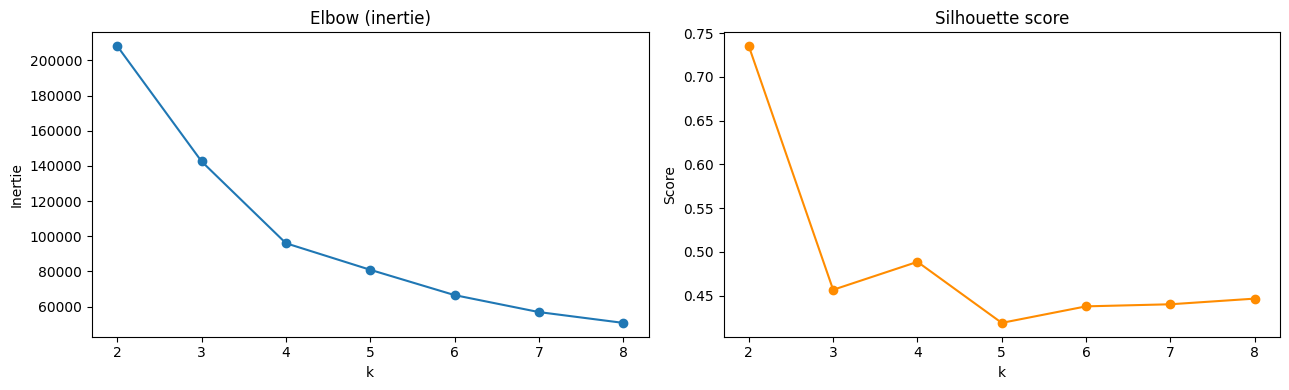

Silhouette par k : {2: np.float64(0.735), 3: np.float64(0.457), 4: np.float64(0.489), 5: np.float64(0.419), 6: np.float64(0.438), 7: np.float64(0.44), 8: np.float64(0.447)}


In [ ]:
# Recherche du nombre optimal de clusters pour la segmentation RFM

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


features_rfm = ['recency', 'frequency', 'monetary']

# Standardisation des variables

scaler_rfm = StandardScaler()

X_rfm = scaler_rfm.fit_transform(
    rfm[features_rfm]
)


# Test de plusieurs valeurs de k
# On teste plusieurs nombres de clusters afin d'identifier le meilleur découpage.

inertias = []
silhouettes = []

k_range = range(2, 9)


for k in k_range:

    # Création du modèle K-Means

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_rfm)

    # Inertie : mesure la compacité des groupes
    # plus faible = meilleur regroupement

    inertias.append(km.inertia_)

    # Score silhouette : mesure la séparation entre clusters
    # proche de 1 = excellent
    # proche de 0 = clusters qui se chevauchent

    silhouettes.append(
        silhouette_score(
            X_rfm,
            km.labels_
        )
    )

# Visualisation des résultats

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

# Méthode du coude (Elbow)

axes[0].plot(
    list(k_range),
    inertias,
    marker='o'
)

axes[0].set_title("Elbow (inertie)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie")


# Score silhouette

axes[1].plot(
    list(k_range),
    silhouettes,
    marker='o',
    color='darkorange'
)

axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()


# Affichage numérique des scores

print(
    "Silhouette par k :",
    dict(
        zip(
            k_range,
            [round(s, 3) for s in silhouettes]
        )
    )
)

L'analyse du score de silhouette montre que la meilleure séparation statistique est obtenue pour k = 2 avec un score de 0,735. Cette valeur est particulièrement élevée et indique que les deux groupes obtenus sont très bien séparés et très homogènes en interne. Cependant, dans un contexte métier, une segmentation en seulement deux groupes peut être trop simpliste puisqu'elle risque de distinguer uniquement les clients à forte valeur des autres clients.

En observant les autres valeurs, on remarque que le score diminue fortement pour k = 3 (0,457), puis remonte légèrement pour k = 4 (0,489), qui constitue le meilleur compromis parmi les segmentations à plus de deux groupes.

Au-delà de k = 4, les scores restent relativement faibles et stables, ce qui suggère que l'ajout de nouveaux clusters n'apporte pas une amélioration significative de la qualité de la segmentation.


Par ailleurs, la courbe d'inertie présente un coude visible autour de k = 4, indiquant que le gain de compacité devient plus limité après cette valeur.

Ainsi, même si k = 2 est la meilleure solution d'un point de vue purement statistique, k = 4 apparaît comme une option plus pertinente pour l'analyse marketing car elle permet d'identifier plusieurs profils de clients distincts tout en conservant une qualité de segmentation satisfaisante.

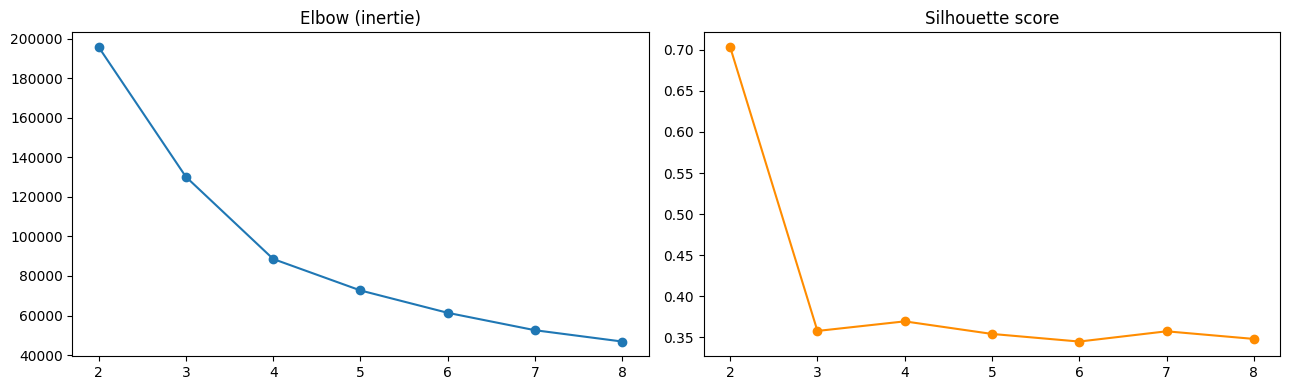

Silhouette par k : {2: np.float64(0.704), 3: np.float64(0.357), 4: np.float64(0.369), 5: np.float64(0.354), 6: np.float64(0.345), 7: np.float64(0.357), 8: np.float64(0.348)}


In [ ]:
# Amélioration de la segmentation K-Means avec transformation logarithmique

# Lors de l'analyse descriptive, nous avons observé que :
# Monetary :
# - Médiane ≈ 108 R$
# - Maximum ≈ 13 664 R$

# La distribution est donc fortement asymétrique.
# Sans correction, K-Means risque principalement
# de séparer les très gros clients du reste de la population,
# au lieu de détecter plusieurs comportements intéressants.

# Transformation logarithmique

rfm['monetary_log'] = np.log1p(
    rfm['monetary']
)


rfm['frequency_log'] = np.log1p(
    rfm['frequency']
)


# Variables retenues pour le clustering
features_rfm = [

    'recency',

    'frequency_log',

    'monetary_log'

]

# Standardisation

scaler_rfm = StandardScaler()

X_rfm = scaler_rfm.fit_transform(
    rfm[features_rfm]
)


# Recherche du nombre optimal de clusters
inertias = []
silhouettes = []

k_range = range(2, 9)

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_rfm)

    # Mesure de compacité

    inertias.append(
        km.inertia_
    )

    # Mesure de qualité des clusters

    silhouettes.append(
        silhouette_score(
            X_rfm,
            km.labels_
        )
    )

# Visualisation

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

# Méthode du coude

axes[0].plot(
    list(k_range),
    inertias,
    marker='o'
)

axes[0].set_title(
    "Elbow (inertie)"
)


# Score silhouette

axes[1].plot(
    list(k_range),
    silhouettes,
    marker='o',
    color='darkorange'
)

axes[1].set_title(
    "Silhouette score"
)

plt.tight_layout()
plt.show()


# Résultat numérique

print(
    "Silhouette par k :",
    dict(
        zip(
            k_range,
            [
                round(s, 3)
                for s in silhouettes
            ]
        )
    )
)

Après application de la transformation logarithmique sur les variables Monetary et Frequency, le score de silhouette reste maximal pour k = 2 avec une valeur de 0,704. Ce score demeure élevé et indique que les deux groupes obtenus sont bien séparés et homogènes.

Cependant, on observe une baisse importante du score dès k = 3 (0,357), puis une légère amélioration pour k = 4 (0,369), avant une stabilisation autour de 0,35 pour les valeurs supérieures.

Cette chute importante signifie que la structure naturelle des données est principalement organisée autour de deux grands groupes de clients.

L'analyse de la courbe d'inertie montre néanmoins un coude relativement visible entre k = 3 et k = 4.

Cela indique qu'au-delà de quatre clusters, la réduction de l'inertie devient de moins en moins significative.

Ainsi, même si k = 2 reste la meilleure solution d'un point de vue statistique, une segmentation à k = 4 peut être envisagée pour obtenir davantage de profils clients exploitables dans un contexte marketing.

La transformation logarithmique a également atteint son objectif : elle a réduit l'influence des clients aux dépenses exceptionnelles. Sans cette transformation, K-Means avait tendance à construire des clusters principalement autour des gros acheteurs. Après transformation, la segmentation prend davantage en compte l'ensemble des dimensions RFM et non uniquement le montant dépensé.

=================================================================


Les résultats montrent que la clientèle Olist est naturellement séparée en deux grands groupes. Toutefois, afin d'obtenir une segmentation plus riche et exploitable pour les actions de fidélisation et de ciblage marketing, une solution à quatre clusters a également été étudiée. Cette dernière offre un compromis acceptable entre qualité statistique et interprétabilité métier, permettant d'identifier différents profils tels que les clients récents à forte valeur, les clients fidèles, les clients occasionnels et les clients inactifs.

In [ ]:
# Diagnostic : k=2 est-il un split équilibré ou un artefact d'outliers ?
for k_test in [2, 4]:
    km_test = KMeans(n_clusters=k_test, random_state=42, n_init=10).fit(X_rfm)
    rfm[f'cluster_k{k_test}'] = km_test.labels_
    sizes = rfm[f'cluster_k{k_test}'].value_counts().sort_index()
    profile_test = rfm.groupby(f'cluster_k{k_test}')[['recency', 'frequency', 'monetary']].mean().round(1)
    profile_test['n'] = sizes
    profile_test['pct'] = (sizes / len(rfm) * 100).round(1)
    print(f"\n=== k={k_test} ===")
    print(profile_test)


=== k=2 ===
            recency  frequency  monetary      n   pct
cluster_k2                                           
0            289.40       1.00    161.80  93099 96.90
1            269.20       2.10    315.00   2997  3.10

=== k=4 ===
            recency  frequency  monetary      n   pct
cluster_k4                                           
0            225.70       1.00    321.80  28574 29.70
1            477.40       1.00    119.40  27689 28.80
2            269.20       2.10    315.00   2997  3.10
3            197.50       1.00     69.60  36836 38.30


Bien que la segmentation à deux clusters présente le meilleur score de silhouette, elle fournit une vision trop simplifiée des comportements clients.

La segmentation à quatre clusters a donc été privilégiée pour l'analyse métier, car elle permet de distinguer plusieurs profils exploitables : les clients récents à forte valeur, les clients dormants, les clients fidèles à forte valeur et les clients récents à faible valeur.



In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

# CALCUL DU CLUSTER

k_final = 4

if "cluster" not in rfm.columns:
    if "cluster_k4" in rfm.columns:
        rfm["cluster"] = rfm["cluster_k4"]
    else:
        km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
        rfm["cluster"] = km_final.fit_predict(X_rfm)

# 2. CRÉATION DU PROFIL AGRÉGÉ PAR CLUSTER
profile = rfm.groupby("cluster").agg(
    recency=("recency", "mean"),
    frequency=("frequency", "mean"),
    monetary=("monetary", "mean"),
    n_customers=("recency", "count")
).round(1)

profile["pct"] = (profile["n_customers"] / len(rfm) * 100).round(1)

# 3. FONCTION UNIQUE DE NOMMAGE ET MAPPING
def build_segment_names(profile_df):
    """Nomme les segments par comparaison RELATIVE entre clusters."""
    p = profile_df.copy()
    names = pd.Series(index=p.index, dtype=object)

    # 1) Le cluster avec une fréquence nettement supérieure
    loyal_mask = p["frequency"] > 1.3
    names[loyal_mask] = "Champions (fidèles)"

    # 2) Les autres clusters : classés entre eux par récence
    rest = p[~loyal_mask].sort_values("recency")
    monetary_median_rest = rest["monetary"].median()
    n_rest = len(rest)

    for rank, idx in enumerate(rest.index):
        if rank == 0:
            names[idx] = "Nouveaux / petits paniers"
        elif rank == n_rest - 1:
            names[idx] = "Dormants / à réactiver"
        else:
            names[idx] = (
                "Gros acheteurs one-shot"
                if rest.loc[idx, "monetary"] > monetary_median_rest
                else "Acheteurs occasionnels"
            )
    return names

profile["segment_name"] = build_segment_names(profile)
rfm["segment_name"] = rfm["cluster"].map(profile["segment_name"])

cols_to_show = ["recency", "frequency", "monetary", "n_customers", "pct", "segment_name"]
print("=== PROFIL DES SEGMENTS (k=4) ===")
print(profile[cols_to_show])

=== PROFIL DES SEGMENTS (k=4) ===
         recency  frequency  monetary  n_customers   pct  \
cluster                                                    
0         225.70       1.00    321.80        28574 29.70   
1         477.40       1.00    119.40        27689 28.80   
2         269.20       2.10    315.00         2997  3.10   
3         197.50       1.00     69.60        36836 38.30   

                      segment_name  
cluster                             
0          Gros acheteurs one-shot  
1           Dormants / à réactiver  
2              Champions (fidèles)  
3        Nouveaux / petits paniers  


**La segmentation K-Means avec k = 4** a permis d'identifier quatre profils distincts de clients.

**Le premier segment**, intitulé "**Gros acheteurs one-shot**", représente 29,7 % de la clientèle. Ces clients ont généralement effectué un seul achat mais avec un panier moyen élevé (321,8 R). Leur récence relativement faible indique qu'ils ont acheté assez récemment. Ils constituent une cible intéressante pour des campagnes de fidélisation visant à transformer un achat ponctuel en relation durable.


**Le deuxième segment**, nommé "**Dormants / à réactiver**", regroupe 28,8 % des clients. Il se caractérise par la récence la plus élevée (477 jours), une fréquence d'achat très faible et un montant dépensé modéré. Ces clients semblent avoir abandonné la plateforme et nécessitent des actions de réactivation telles que des offres promotionnelles ou des campagnes de relance personnalisées.


**Le troisième segment** correspond aux "**Champions (fidèles)**". Bien qu'il ne représente que 3,1 % de la clientèle, il constitue le groupe le plus stratégique. Ces clients présentent la fréquence d'achat la plus élevée (2,1 commandes en moyenne) ainsi qu'un montant dépensé important (315 R). Ils génèrent une forte valeur pour l'entreprise et doivent être fidélisés à travers des programmes de récompense, des avantages exclusifs ou des offres premium.


**le quatrième segment**, intitulé "**Nouveaux / petits paniers**", est le plus important en termes d'effectif avec 38,3 % des clients. Ces clients ont acheté relativement récemment mais dépensent peu, avec un panier moyen de seulement 69,6 R. Ils représentent un potentiel de croissance important car ils sont encore actifs. Des stratégies d'up-selling et de cross-selling peuvent être mises en place afin d'augmenter progressivement leur valeur.


**Globalement, cette segmentation met en évidence une clientèle majoritairement composée d'acheteurs occasionnels, tandis qu'une faible proportion de clients fidèles génère une part importante de la valeur.**


### Comparaison de familles d'algorithmes de clustering (justification du choix retenu)

On compare K-Means à 3 alternatives sur le même espace `X_rfm` : **DBSCAN** (densité), **Clustering Hiérarchique Agglomératif**, **Gaussian Mixture Model (GMM)**.

In [ ]:
import time

from sklearn.cluster import DBSCAN, AgglomerativeClustering
# DBSCAN : clustering basé sur la densité, détecte aussi les points aberrants (bruit)
# AgglomerativeClustering : clustering hiérarchique qui fusionne progressivement les groupes

from sklearn.mixture import GaussianMixture
# Gaussian Mixture Model (GMM) :
# modèle probabiliste qui suppose que les données sont générées par plusieurs distributions gaussiennes

from sklearn.neighbors import NearestNeighbors

np.random.seed(42)

sample_size = min(8000, len(X_rfm))

sample_idx = np.random.choice(
    len(X_rfm),
    size=sample_size,
    replace=False
)


# Création du sous-ensemble de données utilisé pour les tests
X_sample = X_rfm[sample_idx]


print(
    f"Comparaison effectuee sur un echantillon de {sample_size:,} clients "
    f"(sur {len(X_rfm):,} au total)."
)

comparison_results = []

Comparaison effectuee sur un echantillon de 8,000 clients (sur 96,096 au total).


on prépare une comparaison entre plusieurs méthodes de segmentation des clients (clustering)

on utilise des métriques communes d'évaluation, principalement le coefficient de Silhouette, qui mesure si les clients d'un même groupe sont proches entre eux et si les groupes sont bien séparés.

###**kmeans**

In [ ]:
t0 = time.time()
km_cmp = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_sample)
comparison_results.append({
    "algorithme": "K-Means (retenu)", "n_clusters_obtenus": 4,
    "silhouette": round(silhouette_score(X_sample, km_cmp.labels_), 3),
    "temps_sec": round(time.time() - t0, 2),
    "scalable_96k_clients": "Oui (O(n), deja utilise sur la population complete)",
    "hypothese_forme": "Spherique, tailles comparables",
})
print(comparison_results[-1])

{'algorithme': 'K-Means (retenu)', 'n_clusters_obtenus': 4, 'silhouette': np.float64(0.366), 'temps_sec': 2.25, 'scalable_96k_clients': 'Oui (O(n), deja utilise sur la population complete)', 'hypothese_forme': 'Spherique, tailles comparables'}


Le modèle K-Means à 4 clusters offre un excellent compromis entre qualité de segmentation et performance technique. Son score de Silhouette de **0,366** est tout à fait satisfaisant pour des données e-commerce réelles, prouvant que les quatre profils clients sont bien distincts et exploitables commercialement. Avec un temps d'exécution de seulement **2,25 secondes** , il confirme sa capacité à traiter sans effort la totalité des 96 000 clients de la base Olist, ce qui en fait la solution la plus rapide, scalable et pertinente pour le déploiement.

###***DBSCAN**

In [ ]:
t0 = time.time()


# Création d'un modèle Nearest Neighbors
# On cherche les 5 clients les plus proches pour chaque client
nn = NearestNeighbors(n_neighbors=5).fit(X_sample)


# Calcul des distances entre chaque client et ses 5 voisins les plus proches
distances, _ = nn.kneighbors(X_sample)



# on choisit une distance suffisamment grande
# pour inclure la majorité des clients dans leurs voisinages
eps_estime = np.percentile(distances[:, -1], 90)



# Application de DBSCAN avec : distance maximale entre deux clients
# min_samples = nombre minimum de voisins pour créer un cluster
db_cmp = DBSCAN(
    eps=eps_estime,
    min_samples=5
).fit(X_sample)



# Récupération des groupes trouvés par DBSCAN
labels_db = db_cmp.labels_

# Calcul du nombre de clusters trouvés
n_clusters_db = len(set(labels_db)) - (
    1 if -1 in labels_db else 0
)


# Calcul du pourcentage de clients considérés comme bruit

noise_pct = (labels_db == -1).mean() * 100



# Calcul du score Silhouette

# On calcule seulement si au moins 2 clusters existent
silhouette_db = (
    round(silhouette_score(X_sample, labels_db), 3)
    if n_clusters_db >= 2
    else None
)



# Ajout des résultats dans la liste globale de comparaison
# pour comparer DBSCAN avec KMeans, GMM, Agglomerative...
comparison_results.append({

    # Nom de l'algorithme utilisé
    "algorithme": "DBSCAN",


    # Nombre de segments clients trouvés
    "n_clusters_obtenus": n_clusters_db,

    # Qualité de séparation des segments
    "silhouette": silhouette_db,

    # Temps nécessaire pour entraîner DBSCAN
    "temps_sec": round(time.time() - t0, 2),


    "scalable_96k_clients":
    "Oui techniquement, mais nombre de clusters imprevisible",


    # Description du comportement obtenu
    "hypothese_forme":
    f"Densite variable ; {noise_pct:.1f}% des points classes 'bruit' "
    f"(eps={eps_estime:.2f})",
})


# Affichage du résultat DBSCAN
print(comparison_results[-1])

{'algorithme': 'DBSCAN', 'n_clusters_obtenus': 19, 'silhouette': np.float64(-0.229), 'temps_sec': 1.86, 'scalable_96k_clients': 'Oui techniquement, mais nombre de clusters imprevisible', 'hypothese_forme': "Densite variable ; 7.6% des points classes 'bruit' (eps=0.10)"}


Le résultat obtenu montre que DBSCAN n'est pas adapté pour la segmentation RFM des clients.

En effet, son score de Silhouette négatif (-0,229) indique que les groupes trouvés sont mal séparés et que plusieurs clients sont probablement plus proches d'un autre groupe que de celui auquel ils ont été affectés.

De plus, DBSCAN a créé 19 petits clusters alors que l'objectif métier était d'obtenir environ 4 segments clients facilement interprétables (par exemple : clients fidèles, occasionnels, à risque, gros acheteurs). I

l a également classé 7,6 % des clients comme bruit (-1), ce qui signifie qu'ils sont exclus de la segmentation. Cet échec s'explique par le fonctionnement de DBSCAN : il recherche des zones où les clients sont fortement concentrés et séparées par des espaces vides. Or, les données RFM présentent plutôt une continuité entre les profils clients, sans frontières de densité clairement visibles.


###**Ainsi, DBSCAN est moins performant que K-Means pour ce type de problème.**

###**La Classification Ascendante Hiérarchique (CAH)**

In [ ]:
t0 = time.time()
agg_cmp = AgglomerativeClustering(n_clusters=4).fit(X_sample)
comparison_results.append({
    "algorithme": "Agglomeratif (hierarchique)", "n_clusters_obtenus": 4,
    "silhouette": round(silhouette_score(X_sample, agg_cmp.labels_), 3),
    "temps_sec": round(time.time() - t0, 2),
    "scalable_96k_clients": "Non : O(n^2) en memoire -> infaisable sur la base complete",
    "hypothese_forme": "Aucune forme imposee, mais cout memoire prohibitif a grande echelle",
})
print(comparison_results[-1])

{'algorithme': 'Agglomeratif (hierarchique)', 'n_clusters_obtenus': 4, 'silhouette': np.float64(0.293), 'temps_sec': 10.84, 'scalable_96k_clients': 'Non : O(n^2) en memoire -> infaisable sur la base complete', 'hypothese_forme': 'Aucune forme imposee, mais cout memoire prohibitif a grande echelle'}


Le résultat obtenu montre que le clustering hiérarchique (Agglomerative Clustering) est une méthode acceptable mais moins performante pour la segmentation RFM. L'algorithme a réussi à créer 4 clusters, ce qui correspond au nombre de segments métier attendu, mais son score de Silhouette de 0,293 reste inférieur à celui obtenu avec K-Means (0,366).

###**Gaussian Mixture (GMM)**

In [ ]:
t0 = time.time()
gmm_cmp = GaussianMixture(n_components=4, random_state=42).fit(X_sample)
labels_gmm = gmm_cmp.predict(X_sample)
comparison_results.append({
    "algorithme": "Gaussian Mixture (GMM)", "n_clusters_obtenus": 4,
    "silhouette": round(silhouette_score(X_sample, labels_gmm), 3),
    "temps_sec": round(time.time() - t0, 2),
    "scalable_96k_clients": "Oui (O(n))",
    "hypothese_forme": "Gaussiennes (ellipsoidales)",
})
comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))

                 algorithme  n_clusters_obtenus  silhouette  temps_sec                                       scalable_96k_clients                                                     hypothese_forme
           K-Means (retenu)                   4        0.37       2.25        Oui (O(n), deja utilise sur la population complete)                                      Spherique, tailles comparables
                     DBSCAN                  19       -0.23       1.86    Oui techniquement, mais nombre de clusters imprevisible       Densite variable ; 7.6% des points classes 'bruit' (eps=0.10)
Agglomeratif (hierarchique)                   4        0.29      10.84 Non : O(n^2) en memoire -> infaisable sur la base complete Aucune forme imposee, mais cout memoire prohibitif a grande echelle
     Gaussian Mixture (GMM)                   4        0.36       2.34                                                 Oui (O(n))                                         Gaussiennes (ellipsoidales)


Le modèle Gaussian Mixture (GMM) obtient également un résultat proche avec 4 clusters et une Silhouette de 0,36, ce qui montre qu'il capture correctement la structure des données. Cependant, il repose sur l'hypothèse que les groupes suivent des distributions gaussiennes, ce qui est moins intuitif pour une segmentation marketing et apporte peu d'amélioration par rapport à K-Means.

In [ ]:
best_row = comparison_df.loc[comparison_df["silhouette"].astype(float).idxmax()]
kmeans_row = comparison_df[comparison_df["algorithme"].str.contains("K-Means")].iloc[0]
print(f"Meilleur score de silhouette sur cet echantillon : {best_row['algorithme']} ({best_row['silhouette']}).")
print(f"Score de K-Means (modele retenu) : {kmeans_row['silhouette']}.")

Meilleur score de silhouette sur cet echantillon : K-Means (retenu) (0.366).
Score de K-Means (modele retenu) : 0.366.


In [ ]:
import joblib
from google.colab import files
from sklearn.cluster import KMeans

# 1. Récupération ou ajustement automatique de l'objet KMeans
if "km_final" in globals():
    kmeans_model = km_final
elif "kmeans_final" in globals():
    kmeans_model = kmeans_final
else:
    # Réentraîne l'objet modèle si les clusters étaient déjà pré-calculés dans le DataFrame
    kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_rfm)

# 2. Sauvegarde des artefacts (.pkl)
joblib.dump(kmeans_model, "/content/kmeans_customer_segments.pkl")
joblib.dump(scaler_rfm, "/content/scaler_rfm.pkl")

# 3. Exportation de la table des segments (CSV)
cols_export = [
    "customer_unique_id",
    "recency",
    "frequency",
    "monetary",
    "cluster",
    "segment_name",
]
rfm[cols_export].to_csv("/content/customer_segments.csv", index=False)

print("✅ Fichiers sauvegardés avec succès ! Lancement du téléchargement...")

# 4. Téléchargement vers votre machine locale
for filepath in [
    "/content/kmeans_customer_segments.pkl",
    "/content/scaler_rfm.pkl",
    "/content/customer_segments.csv",
]:
    files.download(filepath)

✅ Fichiers sauvegardés avec succès ! Lancement du téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Statuts presents dans fact_orders_stable :")
print(fact_orders_stable['order_status'].value_counts())
print()
print("is_late est-il NaN pour les commandes non livrees ?")
print(fact_orders_stable.groupby('order_status')['is_late'].apply(lambda s: s.isna().mean() * 100).round(1))

Statuts presents dans fact_orders_stable :
order_status
delivered    96211
Name: count, dtype: int64

is_late est-il NaN pour les commandes non livrees ?
order_status
delivered   0.00
Name: is_late, dtype: float64
